# OSHA ITA 2023: primer entregable del proyecto de Machine Learning

**Pregunta:** ¿En qué medida las características estructuradas del lugar de trabajo, la ocupación y el incidente permiten clasificar los cuatro resultados registrados en incidentes posteriores de 2023, en establecimientos no usados para desarrollar el modelo?

La unidad es un caso reportado, no un trabajador expuesto. Se evalúa clasificación retrospectiva: los códigos SOC fueron asignados por OSHA después del reporte y no se dispone de historiales de actualización de los campos. La fecha ordena incidentes, no demuestra que el modelo o las etiquetas estuvieran disponibles en esa fecha. No se predice ocurrencia de lesiones ni se atribuyen causas.

Desarrollo: casos de enero a septiembre en el 40 % de establecimientos asignado al desarrollo, con una purga de siete días antes del corte. Prueba: octubre–diciembre únicamente en el 60 % de establecimientos reservado para prueba. Ningún establecimiento aparece en ambos grupos. La validación interna también separa establecimientos y avanza en el tiempo.

**Exposición histórica:** el trimestre final y métricas agregadas de su evaluación anterior ya se revisaron durante el proyecto. Esta evaluación por empresas y tiempo se fija sin seleccionar empresas por desempeño, pero no es una prueba completamente inédita.

**Fuentes:** [datos OSHA](https://www.osha.gov/itadata), [diccionario](https://www.osha.gov/sites/default/files/case_detail_data_dictionary.pdf), [guía](https://www.osha.gov/sites/default/files/ITA_data_users_guide.pdf). Acceso público; no se afirma una licencia de redistribución no documentada.


## 1. Base de datos, estructura y diccionario de variables

La base contiene datos administrativos de casos OSHA Form 300/301 reportados mediante ITA. Para este proyecto se consideran **890.934 casos** y **91.334 establecimientos** en el archivo original. Los casos están agrupados por establecimiento. La evaluación primaria separa las empresas y los periodos; se reportan métricas por clase y bootstrap por establecimiento.

**Tipo de datos:** datos de eventos individuales con agrupación por establecimiento y fecha del incidente. No constituyen una serie temporal regular de una sola entidad.

| Variable | Tipo / unidad | Significado y uso |
|---|---|---|
| `incident_outcome` | Categórica nominal, códigos 1–4 | **Objetivo.** 1 = Death, 2 = días de ausencia, 3 = traslado/restricción, 4 = otro caso registrable. |
| `state` | Categórica | Estado o territorio reportado. Predictor. |
| `naics_code` | Categórica, código NAICS | Actividad económica del establecimiento. Predictor. |
| `establishment_type` | Categórica | Tipo de establecimiento: privado, gobierno estatal o gobierno local. Predictor. |
| `soc_code` | Categórica, código SOC | Ocupación del trabajador. El código `9999` se interpreta como no codificado. Predictor. |
| `type_of_incident` | Categórica, códigos 1–6 | Tipo general de lesión o enfermedad. Predictor. |
| `time_unknown` | Categórica binaria | Indicador de que la hora del incidente se reportó como desconocida. Predictor. |
| `time_started_work_hour` | Numérica discreta, hora 0–23 | Hora derivada de `time_started_work`. Predictor. |
| `time_of_incident_hour` | Numérica discreta, hora 0–23 | Hora derivada de `time_of_incident`; se deja faltante si la hora se reportó como desconocida. Predictor. |
| `establishment_id` | Identificador de grupo | **No entra al modelo.** Se usa para separar grupos, auditar dependencia y calcular incertidumbre agrupada. |

Variables como `dafw_num_away`, `djtr_num_tr` y `date_of_death` se reservan para auditoría porque revelan directamente el desenlace. Identificadores, nombres y direcciones tampoco se utilizan como predictores.

**Cobertura y ética:** la obligación de detalle 300/301 se refiere a establecimientos de ≥100 empleados en industrias designadas; la publicación también conserva envíos de establecimientos no obligados. No es una muestra representativa de todos los trabajadores ni incluye establecimientos sin casos registrables en este archivo. Véase [alcance oficial de OSHA](https://www.osha.gov/itadata). Los resultados condicionan a tener un caso reportado. Las combinaciones de fechas, ocupación y lugar, especialmente en casos raros, mantienen riesgo de reidentificación aunque se excluyan nombres del modelo: no se publican narrativas, identidades ni ejemplos individuales; el paquete omite el CSV original. Los artefactos de predicción conservan identificadores para auditoría y tampoco deben tratarse como datos anonimizados. No se propone usarlos para decisiones laborales individuales.


### 1.1 Entorno y reproducibilidad


In [1]:
%matplotlib inline
import sys, json, hashlib
sys.dont_write_bytecode = True
from pathlib import Path
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from IPython.display import display, Markdown

assert Path(sys.prefix).name.lower() == 'ml_env', 'Seleccione el núcleo existente ml_env.'
from pathlib import Path
import os

PROJECT_DIR = Path.cwd()
env_data_dir = os.getenv("OSHA_DATA_DIR")

candidates = [
    Path(env_data_dir) if env_data_dir else None,
    Path.cwd(),
    Path.cwd() / "data",
    Path.cwd() / "osha",
]

candidates = [p for p in candidates if p is not None]

DATA_DIR = next(
    p for p in candidates
    if (p / "ITA Case Detail Data 2023 through 12-31-2023OIICS.csv").exists()
)

DATA_PATH = DATA_DIR / "ITA Case Detail Data 2023 through 12-31-2023OIICS.csv"
RESULTS_PATH = next(p for p in [PROJECT_DIR/'osha_screening_results.json', PROJECT_DIR.parent/'osha_screening_results.json'] if p.exists())
UTILS_PATH = PROJECT_DIR/'eda_utils.py'
sys.path.insert(0, str(UTILS_PATH.parent))
import eda_utils as eda
raw_signature = (DATA_PATH.stat().st_size, DATA_PATH.stat().st_mtime_ns)
utils_hash = hashlib.sha256(UTILS_PATH.read_bytes()).hexdigest()
screening = json.loads(RESULTS_PATH.read_text(encoding='utf-8'))
baseline = screening['baseline']
TARGET, GROUP = 'incident_outcome', 'establishment_id'
OUTCOMES = {1:'Fallecimiento (Death)', 2:'Días de ausencia', 3:'Traslado / restricción', 4:'Otro caso registrable'}
INCIDENTS = {'1':'Lesión', '2':'Trastorno cutáneo', '3':'Afección respiratoria', '4':'Intoxicación', '5':'Pérdida auditiva', '6':'Otra enfermedad'}
SECTORS = {'11':'Agricultura / silvicultura', '21':'Minería', '22':'Servicios públicos', '23':'Construcción',
           '31-33':'Manufactura', '42':'Comercio mayorista', '44-45':'Comercio minorista', '48-49':'Transporte / almacenamiento',
           '51':'Información', '52':'Finanzas', '53':'Actividades inmobiliarias', '54':'Servicios profesionales',
           '55':'Dirección empresarial', '56':'Servicios administrativos / residuos', '61':'Educación',
           '62':'Salud / asistencia social', '71':'Arte / recreación', '72':'Alojamiento / alimentación',
           '81':'Otros servicios', '92':'Administración pública'}
pd.set_option('display.max_rows', 60)
pd.set_option('display.max_columns', 12)
pd.set_option('display.float_format', lambda x: f'{x:,.3f}')
sns.set_theme(style='whitegrid', context='notebook')
plt.rcParams.update({'figure.dpi':110, 'axes.spines.top':False, 'axes.spines.right':False})
print('Python:', sys.executable)
print('pandas:', pd.__version__)
print('Utilidades de EDA:', eda.__file__)
print('Tamaño del CSV original en bytes:', raw_signature[0])


# Adaptadores de presentación: conservan datos, identificadores y cálculos.
import builtins
from matplotlib.text import Text
_display_original = display
_show_original = getattr(plt.show, '_osha_original', plt.show)
PRESENTATION_ES = {'value': 'Valor', 'missing_n': 'Faltantes (n)', 'missing_pct': 'Faltantes (%)', 'cases': 'Casos', 'outcome': 'Resultado', 'percent': 'Porcentaje', 'role': 'Función', 'column': 'Variable', 'dtype': 'Tipo', 'count': 'Conteo', 'mean': 'Media', 'std': 'Desviación estándar', 'min': 'Mínimo', 'max': 'Máximo', 'variable': 'Variable', 'unique_values': 'Valores distintos', 'most_common': 'Valor más frecuente', 'most_common_n': 'Frecuencia máxima', 'total_cases': 'Total de casos', 'nonmissing_raw': 'Registros originales presentes', 'minutes_equal_00': 'Minutos iguales a 00', 'unusable_or_unknown_hour': 'Hora desconocida o no utilizable', 'reported_cases': 'Casos reportados', 'distinct_outcomes': 'Resultados distintos', 'largest_outcome_share': 'Proporción del resultado más frecuente', 'establishments_with_inconsistent_values': 'Establecimientos con valores inconsistentes', 'cases_or_groups': 'Casos o grupos', 'logistic_regression': 'LogisticRegression histórico', 'constant_reference': 'Referencia constante', 'precision': 'Precisión', 'recall': 'Sensibilidad', 'f1-score': 'F1', 'support': 'Casos', 'Shape:': 'Dimensiones:', 'Duplicated rows:': 'Filas duplicadas:', 'Data types:': 'Tipos de datos:', 'First rows:': 'Primeras filas:', 'Uncoded': 'Sin codificar', 'Laborers and Freight, Stock, and Material Movers, Hand': 'Trabajadores de carga y movimiento manual de materiales', 'Registered Nurses': 'Profesionales de enfermería', 'Stockers and Order Fillers': 'Reponedores y preparadores de pedidos', 'Nursing Assistants': 'Auxiliares de enfermería', 'Couriers and Messengers': 'Mensajeros', 'Heavy and Tractor-Trailer Truck Drivers': 'Conductores de camiones pesados y tractocamiones', 'Assemblers and Fabricators, All Other': 'Otros ensambladores y fabricantes', 'Fast Food and Counter Workers': 'Trabajadores de comida rápida y mostrador', 'Cashiers': 'Cajeros', 'Count': 'Casos'}
def text_es(value):
    if not isinstance(value,str): return value
    return PRESENTATION_ES.get(value,value)
def display(*objects, **kwargs):
    translated=[]
    for obj in objects:
        if isinstance(obj,pd.DataFrame):
            obj=obj.rename(index=text_es,columns=text_es)
            obj.index.names=[text_es(v) for v in obj.index.names]
            obj.columns.names=[text_es(v) for v in obj.columns.names]
        elif isinstance(obj,pd.Series): obj=obj.rename(index=text_es).rename(text_es(obj.name))
        translated.append(obj)
    return _display_original(*translated,**kwargs)
def print_es(*args, **kwargs):
    args=[a.replace('Shape:','Dimensiones:').replace('Duplicated rows:','Filas duplicadas:').replace('Data types:','Tipos de datos:').replace('First rows:','Primeras filas:') if isinstance(a,str) else a for a in args]
    return builtins.print(*args,**kwargs)
def show_es(*args, **kwargs):
    for number in plt.get_fignums():
        figure=plt.figure(number)
        for ax in figure.axes:
            if ax.get_title().startswith('Distribution of '):
                label=ax.get_title().removeprefix('Distribution of ')
                label={'incident_type':'tipo de incidente','establishment_type_label':'tipo de establecimiento'}.get(label,label)
                ax.set_title('Distribución del '+label)
            for axis in ['x','y']:
                getter=getattr(ax,'get_'+axis+'ticklabels')
                old=[t.get_text() for t in getter()]; new=[text_es(s) for s in old]
                if old!=new:
                    limits=getattr(ax,'get_'+axis+'lim')()
                    getattr(ax,'set_'+axis+'ticks')(getattr(ax,'get_'+axis+'ticks')(),new)
                    getattr(ax,'set_'+axis+'lim')(limits)
            ax.set_xlabel({'incident_type':'Tipo de incidente','establishment_type_label':'Tipo de establecimiento'}.get(ax.get_xlabel(),text_es(ax.get_xlabel())))
            ax.set_ylabel(text_es(ax.get_ylabel()))
        for artist in figure.findobj(Text):artist.set_text(text_es(artist.get_text()))
        figure.tight_layout()
    return _show_original(*args,**kwargs)
eda.display=display
eda.print=print_es
show_es._osha_original=_show_original
plt.show=show_es


Python: c:\Users\ivanj\miniconda3\envs\ml_env\python.exe
pandas: 1.5.3
Utilidades de EDA: D:\Documents\Personal\Uninorte\Maestría\Primer semestre\Machine Learning\Tareas\tarea\osha\eda_utils.py
Tamaño del CSV original en bytes: 654687687


## 2. Inventario del archivo original y valores faltantes

Se reutiliza la auditoría completa de `osha_screening_results.json` (890.934 registros). La ausencia estructural de una fecha de fallecimiento en un caso no mortal no equivale a una característica desconocida. El código ocupacional `9999` significa que la ocupación no fue codificada y también representa información faltante.

El archivo falló con decodificación estricta UTF-8 y Windows-1252 durante el cribado. Latin-1 conserva los bytes para inspeccionar campos estructurados, pero **no identifica la codificación original**. No se usan narrativas en EDA ni modelado; la auditoría adicional de coincidencias las lee temporalmente para comparar contenido, sin mostrarlas ni exportarlas. Como el cargador genérico supone UTF-8, se utiliza `pd.read_csv` para este archivo sin modificar las utilidades.


In [2]:
display(pd.Series({
    'Filas originales':screening['rows'], 'Columnas originales':screening['column_count'],
    'Establecimientos distintos':screening['unique_establishments'],
    'Identificadores ITA distintos':screening['rows']-screening['duplicate_id_extra_rows'],
    'Filas duplicadas exactas adicionales (comprobación hash)':screening['exact_duplicate_extra_rows_hash_check'],
    'Repeticiones adicionales de establecimiento/número de caso':screening['duplicate_establishment_case_extra_rows'],
    'Filas con clave establecimiento/número de caso repetida':screening['duplicate_establishment_case_all_rows'],
    'Coincidencias sin ID, número de caso ni fecha de envío':screening['duplicate_content_excluding_id_case_submission_time_extra_rows'],
    'Fechas de incidente fuera de 2023':screening['outside_2023']
}, name='value').to_frame())
print('Intervalo de fechas del incidente:', screening['date_min'], 'a', screening['date_max'])
raw_missing = pd.Series(screening['missing_counts'], name='missing_n').to_frame()
raw_missing['missing_pct'] = 100*raw_missing.missing_n/screening['rows']
display(raw_missing.sort_values('missing_pct', ascending=False))
raw_target = pd.Series(screening['distributions'][TARGET], dtype='int64')
raw_target.index = raw_target.index.astype(int)
raw_target = raw_target.sort_index().rename('cases').to_frame()
raw_target['outcome'] = raw_target.index.map(OUTCOMES)
raw_target['percent'] = 100*raw_target.cases/screening['rows']
display(raw_target[['outcome','cases','percent']])


,Valor
Filas originales,890934
Columnas originales,49
Establecimientos distintos,91334
Identificadores ITA distintos,890934
Filas duplicadas exactas adicionales (comprobación hash),0
Repeticiones adicionales de establecimiento/número de caso,64748
Filas con clave establecimiento/número de caso repetida,80437
"Coincidencias sin ID, número de caso ni fecha de envío",7250
Fechas de incidente fuera de 2023,562


Intervalo de fechas del incidente: 2022-02-26 00:00:00 a 2024-12-12 00:00:00


,Faltantes (n),Faltantes (%)
date_of_death,890652,99.968
sec_source_code_pred,701147,78.698
sec_source_title_pred,701147,78.698
part_title_pred,286308,32.136
part_code_pred,286308,32.136
time_started_work,112459,12.623
time_of_incident,111264,12.488
event_title_pred,85324,9.577
event_code_pred,85324,9.577
ein,76776,8.617


,Resultado,Casos,Porcentaje
1,Fallecimiento (Death),282,0.032
2,Días de ausencia,324939,36.472
3,Traslado / restricción,263687,29.597
4,Otro caso registrable,302026,33.900


## 3. Función de las variables y exclusiones por fuga de información

`incident_outcome` se trata como una variable nominal: 1 = fallecimiento (Death), 2 = días de ausencia, 3 = traslado o restricción laboral y 4 = otro caso registrable. La media, la correlación de Pearson y las gráficas de regresión sobre estos códigos no tienen una interpretación válida. Las tres clases no mortales tienen suficiente representación; Death es extremadamente infrecuente. No se redefine el objetivo.

Los días de ausencia, los días de restricción y la fecha de fallecimiento revelan el resultado final. Solo se examinan para auditar coherencia. Las variables OIICS `*_pred` se derivan de narrativas y se excluyen; no está establecida su disponibilidad independiente antes del desenlace. Los códigos SOC describen la ocupación, no las consecuencias de la lesión, pero su asignación retrospectiva desde descripciones del puesto introduce incertidumbre. Se usa como representación retrospectiva de ocupación; no se afirma disponibilidad de ese código en el momento del incidente.

Las medidas anuales de personal se usan únicamente para descripción: su periodo puede extenderse más allá del incidente. Se conservan industria y estado, y se excluyen nombres y ubicaciones detalladas que puedan identificar establecimientos. Se mantiene la lista original de ocho predictores.


In [3]:
roles = {}
for c in screening['columns']:
    if c == TARGET: reason = 'Objetivo: resultado final registrado'
    elif c in baseline['raw_feature_columns']: reason = 'Predictor estructurado conservado (tiempos convertidos a hora)'
    elif c == GROUP: reason = 'Solo agrupación; excluido como predictor'
    elif c in ['dafw_num_away','djtr_num_tr','date_of_death']: reason = 'Fuga directa del resultado; solo auditoría'
    elif c.endswith('_pred'): reason = 'Predicción OIICS derivada de narrativas; excluida'
    elif c.startswith('NEW_') or c == 'job_description': reason = 'Texto libre; excluido'
    elif c in ['size','annual_average_employees','total_hours_worked']: reason = 'Resumen anual potencialmente posterior al incidente; excluido'
    elif c in ['industry_description','soc_description']: reason = 'Solo etiqueta descriptiva; redundante con el código'
    elif c in ['id','case_number','ein','establishment_name','company_name','street_address','city','zip_code']: reason = 'Identificador o sustituto del establecimiento; excluido'
    else: reason = 'Fecha o metadatos de envío/codificación; excluidos'
    roles[c] = reason
display(pd.Series(roles, name='role').rename_axis('column').to_frame())
print('Predictores conservados de la línea base:', ', '.join(baseline['features']))

display(Markdown('### Disponibilidad y auditoría predictiva univariable'))
display(pd.DataFrame([
 {'Campo':'state / naics_code / establishment_type','Disponibilidad':'Contexto del lugar de trabajo; versión de publicación, sin historial de cambios'},
 {'Campo':'soc_code','Disponibilidad':'Asignado retrospectivamente por OSHA; no disponible históricamente demostrado'},
 {'Campo':'type_of_incident','Disponibilidad':'Clasificación administrativa de lesión/enfermedad; momento de determinación no documentado'},
 {'Campo':'time_started_work / time_of_incident / time_unknown','Disponibilidad':'Describe el evento; precisión y momento de registro no demostrados'},
 {'Campo':'incident_outcome','Disponibilidad':'Resultado más serio registrado, no necesariamente conocido inmediatamente'}]))
print('El momento analítico es posterior al procesamiento del reporte. La cronología es de incidentes, no de disponibilidad histórica de etiquetas.')


,Función
Variable,
id,Identificador o sustituto del establecimiento;...
establishment_id,Solo agrupación; excluido como predictor
establishment_name,Identificador o sustituto del establecimiento;...
ein,Identificador o sustituto del establecimiento;...
company_name,Identificador o sustituto del establecimiento;...
street_address,Identificador o sustituto del establecimiento;...
city,Identificador o sustituto del establecimiento;...
state,Predictor estructurado conservado (tiempos con...
zip_code,Identificador o sustituto del establecimiento;...


Predictores conservados de la línea base: state, naics_code, establishment_type, soc_code, type_of_incident, time_unknown, time_started_work_hour, time_of_incident_hour


### Disponibilidad y auditoría predictiva univariable

,Campo,Disponibilidad
0,state / naics_code / establishment_type,Contexto del lugar de trabajo; versión de publ...
1,soc_code,Asignado retrospectivamente por OSHA; no dispo...
2,type_of_incident,Clasificación administrativa de lesión/enferme...
3,time_started_work / time_of_incident / time_un...,Describe el evento; precisión y momento de reg...
4,incident_outcome,"Resultado más serio registrado, no necesariame..."


El momento analítico es posterior al procesamiento del reporte. La cronología es de incidentes, no de disponibilidad histórica de etiquetas.


## 4. Partición por empresas y tiempo

Se conservan los incidentes de 2023. Antes de los análisis del desarrollo, se asignan aleatoriamente y sin usar resultados el 60 % de los establecimientos a la prueba (semilla 42). Esta proporción es un compromiso de diseño: el preanálisis deja 39 fallecimientos para la prueba y conserva 269.516 casos de desarrollo; no se eligió con métricas del modelo y no es un porcentaje exigido por el curso. El desarrollo usa casos del 40 % restante hasta el 23 de septiembre; la prueba usa únicamente casos del trimestre final de establecimientos reservados. Se purgan siete días antes de cada periodo de validación/prueba para reducir dependencia temporal inmediata. Los casos de establecimientos reservados fuera del trimestre de prueba y los del trimestre final de empresas de desarrollo se excluyen de estos ajustes. La prueba histórica ya había sido examinada; esta evaluación nueva no es inédita.


In [4]:
audit_columns = ['id',GROUP,'case_number',TARGET,'date_of_incident','date_of_death',
                 'dafw_num_away','djtr_num_tr','annual_average_employees','total_hours_worked',
                 'size','soc_description','naics_year']
load_columns = list(dict.fromkeys(baseline['raw_feature_columns'] + audit_columns))
assert pd.read_csv(DATA_PATH, nrows=0, encoding='latin1').columns.tolist() == screening['columns']
structured = pd.read_csv(DATA_PATH, usecols=load_columns, dtype=str, encoding='latin1')
structured = eda.clean_string_columns(structured).replace(r'^\s*$', np.nan, regex=True)
assert len(structured) == screening['rows'] and structured.id.is_unique
structured['incident_date'] = pd.to_datetime(structured.date_of_incident, format='%m/%d/%Y', errors='coerce')
eligible = structured.incident_date.dt.year.eq(2023)
assert int((~eligible).sum()) == baseline['excluded_rows']
all_groups = np.sort(structured.loc[eligible, GROUP].dropna().unique())
heldout_group_ids = set(np.random.default_rng(42).permutation(all_groups)[:int(np.floor(0.60 * len(all_groups)))])
is_heldout_group = structured[GROUP].isin(heldout_group_ids)
cutoff = pd.Timestamp('2023-10-01')
gap_days = 7
development_mask = eligible & ~is_heldout_group & structured.incident_date.lt(cutoff - pd.Timedelta(days=gap_days))
test_mask = eligible & is_heldout_group & structured.incident_date.ge(cutoff)
excluded_design_rows = int((eligible & ~(development_mask | test_mask)).sum())
train = structured.loc[development_mask].copy()
holdout_rows = int(test_mask.sum())
holdout_groups = int(structured.loc[test_mask, GROUP].nunique())
assert len(train) == 269516 and holdout_rows == 127391
test_group_ids = set(structured.loc[test_mask, GROUP])
assert not set(train[GROUP]).intersection(test_group_ids)
assert train.incident_date.max() < cutoff - pd.Timedelta(days=gap_days)
assert set(train[TARGET].astype(int)) == set(structured.loc[test_mask, TARGET].astype(int)) == {1, 2, 3, 4}
print('Establecimientos 2023:', len(all_groups), '| reservados para prueba:', len(heldout_group_ids))
print('Desarrollo:', len(train), 'casos y', train[GROUP].nunique(), 'establecimientos')
print('Prueba:', holdout_rows, 'casos y', holdout_groups, 'establecimientos')
print('Filas excluidas por el diseño grupo-tiempo:', excluded_design_rows)
del structured, eligible, is_heldout_group, development_mask, test_mask
train[TARGET] = pd.to_numeric(train[TARGET]).astype(int)
train['outcome'] = train[TARGET].map(OUTCOMES)
train['incident_type'] = train.type_of_incident.map(INCIDENTS).fillna('Código desconocido')
train['industry_sector_code'] = train.naics_code.str[:2].replace({'31':'31-33','32':'31-33','33':'31-33','44':'44-45','45':'44-45','48':'48-49','49':'48-49'})
train['industry_sector'] = train.industry_sector_code.map(SECTORS).fillna('Código sin correspondencia')
train['establishment_type_label'] = train.establishment_type.map({'1':'Sector privado','2':'Gobierno estatal','3':'Gobierno local'}).fillna('Desconocido')
train['soc_code'] = train.soc_code.replace({'9999':np.nan,'0000':np.nan})
for c in ['time_started_work','time_of_incident']:
    hour = pd.to_numeric(train[c].str.extract(r'^(\d{1,2}):', expand=False), errors='coerce')
    train[c+'_hour'] = hour.where(hour.between(0,23))
train.loc[train.time_unknown.eq('1'),'time_of_incident_hour'] = np.nan
for c in ['dafw_num_away','djtr_num_tr','annual_average_employees','total_hours_worked']:
    train[c] = pd.to_numeric(train[c], errors='coerce')
feature_view = train[baseline['features']].copy()
for c in baseline['features'][:6]:
    feature_view[c] = feature_view[c].astype('category')
eda_view = feature_view.assign(outcome=train.outcome.astype('category'), case_id=train.id)
print('El EDA siguiente utiliza SOLO EL DESARROLLO ENERO–SEPTIEMBRE')
print('Entrenamiento:', len(train), 'casos;', train[GROUP].nunique(), 'establecimientos')
print('Reserva conservada:', holdout_rows, 'casos;', holdout_groups, 'establecimientos')
print('Columnas estructuradas cargadas:', len(load_columns), 'de', screening['column_count'])


Establecimientos 2023: 91256 | reservados para prueba: 54753
Desarrollo: 269516 casos y 34029 establecimientos
Prueba: 127391 casos y 34182 establecimientos
Filas excluidas por el diseño grupo-tiempo: 493465


El EDA siguiente utiliza SOLO EL DESARROLLO ENERO–SEPTIEMBRE
Entrenamiento: 269516 casos; 34029 establecimientos
Reserva conservada: 127391 casos; 34182 establecimientos
Columnas estructuradas cargadas: 21 de 49


## 5. Resumen general y valores faltantes en los predictores

Las funciones reutilizables proporcionan descripción general, detección de tipos, faltantes y resúmenes numéricos y categóricos. Los perfiles de predictores repetidos pueden corresponder a casos distintos; se muestra el identificador del caso para no confundirlos con registros duplicados. Los códigos son categorías, no medidas continuas. La hora es cíclica y su resumen aritmético es solamente descriptivo.

Los adaptadores locales traducen únicamente la presentación de tablas, mensajes y gráficas; no cambian los identificadores de código, las columnas originales ni los cálculos de `eda_utils.py`.


Dimensiones: (269516, 10)
Filas duplicadas: 0

Tipos de datos:


,Tipo
state,category
naics_code,category
establishment_type,category
soc_code,category
type_of_incident,category
time_unknown,category
time_started_work_hour,float64
time_of_incident_hour,float64
Resultado,category
case_id,object



Primeras filas:


,state,naics_code,establishment_type,soc_code,type_of_incident,time_unknown,time_started_work_hour,time_of_incident_hour,Resultado,case_id
13,NY,311421,1,51-9199,6,1,7.000,NaN,Días de ausencia,693
14,MI,484220,1,53-3032,1,0,6.000,8.000,Días de ausencia,694
15,GA,332312,1,51-9021,1,0,6.000,13.000,Días de ausencia,695
16,WV,333131,1,51-4041,1,0,3.000,6.000,Otro caso registrable,696
18,MI,321113,1,53-7062,1,0,6.000,14.000,Traslado / restricción,698


,Conteo,Media,Desviación estándar,Mínimo,25%,50%,75%,Máximo
time_started_work_hour,"236,501.000",9.375,5.412,0.000,6.000,7.000,13.000,23.000
time_of_incident_hour,"233,239.000",11.793,5.539,0.000,8.000,12.000,16.000,23.000


,Variable,Valores distintos,Faltantes (n),Valor más frecuente,Frecuencia máxima
0,state,55,0,CA,35858
1,naics_code,715,0,622110,45062
2,establishment_type,4,307,1,252547
3,soc_code,598,51019,NaN,51019
4,type_of_incident,6,0,1,241682
5,time_unknown,2,552,0,233178


,Faltantes (n),Faltantes (%)
soc_code,51019,18.930
time_of_incident_hour,36277,13.460
time_started_work_hour,33015,12.250
time_unknown,552,0.205
establishment_type,307,0.114


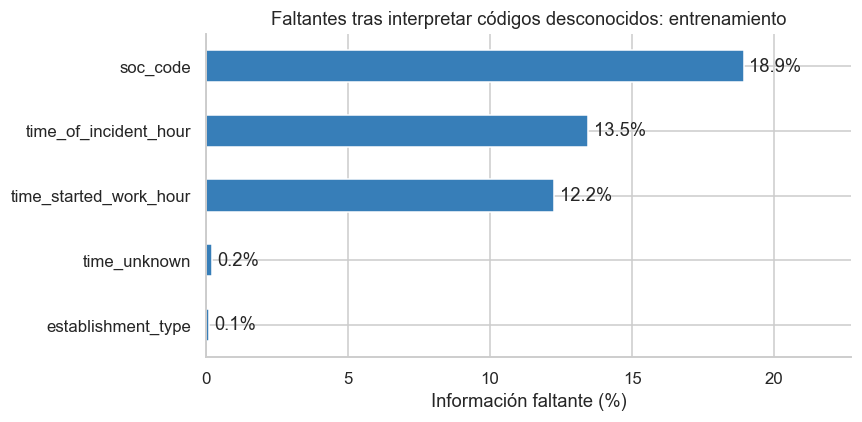

,state,naics_code,establishment_type,soc_code,type_of_incident,time_unknown,time_started_work_hour,time_of_incident_hour
Resultado,,,,,,,,
Fallecimiento (Death),0.000,0.000,0.000,15.942,0.000,0.000,13.043,13.043
Días de ausencia,0.000,0.000,0.067,17.746,0.000,0.206,12.964,16.201
Traslado / restricción,0.000,0.000,0.114,18.659,0.000,0.162,10.099,9.747
Otro caso registrable,0.000,0.000,0.166,20.486,0.000,0.242,13.367,13.718


Los mayores porcentajes de información no utilizable son: **soc_code**: 18.93 %; **time_of_incident_hour**: 13.46 %; **time_started_work_hour**: 12.25 %. Se conserva una categoría explícita de desconocido; no se eliminan casos por faltantes de predictores.

In [5]:
eda.basic_overview(eda_view)
numeric_cols, categorical_cols = eda.get_column_types(feature_view)
display(eda.numeric_summary(feature_view, numeric_cols))
display(eda.categorical_summary(feature_view, categorical_cols))
predictor_missing = eda.missing_values_summary(feature_view)
display(predictor_missing)
fig, ax = plt.subplots(figsize=(8,4))
predictor_missing.missing_pct.sort_values().plot.barh(ax=ax, color='#377eb8')
ax.set(xlabel='Información faltante (%)', ylabel='', title='Faltantes tras interpretar códigos desconocidos: entrenamiento')
for p in ax.patches:
    ax.text(p.get_width()+0.2, p.get_y()+p.get_height()/2, f'{p.get_width():.1f}%', va='center')
ax.set_xlim(0, max(1,predictor_missing.missing_pct.max())*1.2)
plt.tight_layout(); plt.show()
missing_by_outcome = feature_view.isna().groupby(train.outcome).mean().mul(100).reindex(OUTCOMES.values())
display(missing_by_outcome)

worst=feature_view.isna().mean().sort_values(ascending=False).head(3)
display(Markdown('Los mayores porcentajes de información no utilizable son: '+ '; '.join(f'**{k}**: {100*v:.2f} %' for k,v in worst.items())+'. Se conserva una categoría explícita de desconocido; no se eliminan casos por faltantes de predictores.'))


Los faltantes pueden reflejar prácticas de reporte. Las asociaciones observadas no prueban MCAR, MAR o MNAR; el tratamiento se justifica con los resultados de desarrollo mostrados arriba.

### 5.1 Análisis unidimensional formal de los predictores

Se resume cada predictor según su naturaleza. Los códigos NAICS, SOC, estado, tipo de establecimiento, tipo de incidente y `time_unknown` son **categóricos**, aunque algunos se almacenen como números. Las dos variables horarias se analizan como horas discretas de un ciclo de 24 horas; por esta razón, media, asimetría y normalidad tienen una interpretación limitada y no deben tratarse como si la hora 23 estuviera lejos de la hora 0.

Para las variables categóricas se reportan cardinalidad, categoría dominante y categorías raras (<1 %). Para las horas se muestran distribución y boxplot únicamente como descripción; no se eliminan valores por IQR porque 0–23 es el rango válido del reloj.


,Variable,Tipo,Cardinalidad,Faltantes (%),Categoría más frecuente,Frecuencia máxima (%),Categorías < 1 %,Casos en categorías < 1 % (%)
0,state,Categórica,55,0.000,CA,13.305,26.000,10.916
1,naics_code,Categórica,715,0.000,622110,16.720,700.000,39.038
2,establishment_type,Categórica,5,0.114,1,93.704,2.000,0.204
3,soc_code,Categórica,599,18.930,Desconocido,18.930,582.000,36.652
4,type_of_incident,Categórica,6,0.000,1,89.673,2.000,0.629
5,time_unknown,Categórica,3,0.205,0,86.517,1.000,0.205
6,time_started_work_hour,Hora discreta (0–23),24,12.250,7.0,15.907,NaN,NaN
7,time_of_incident_hour,Hora discreta (0–23),24,13.460,10.0,6.567,NaN,NaN


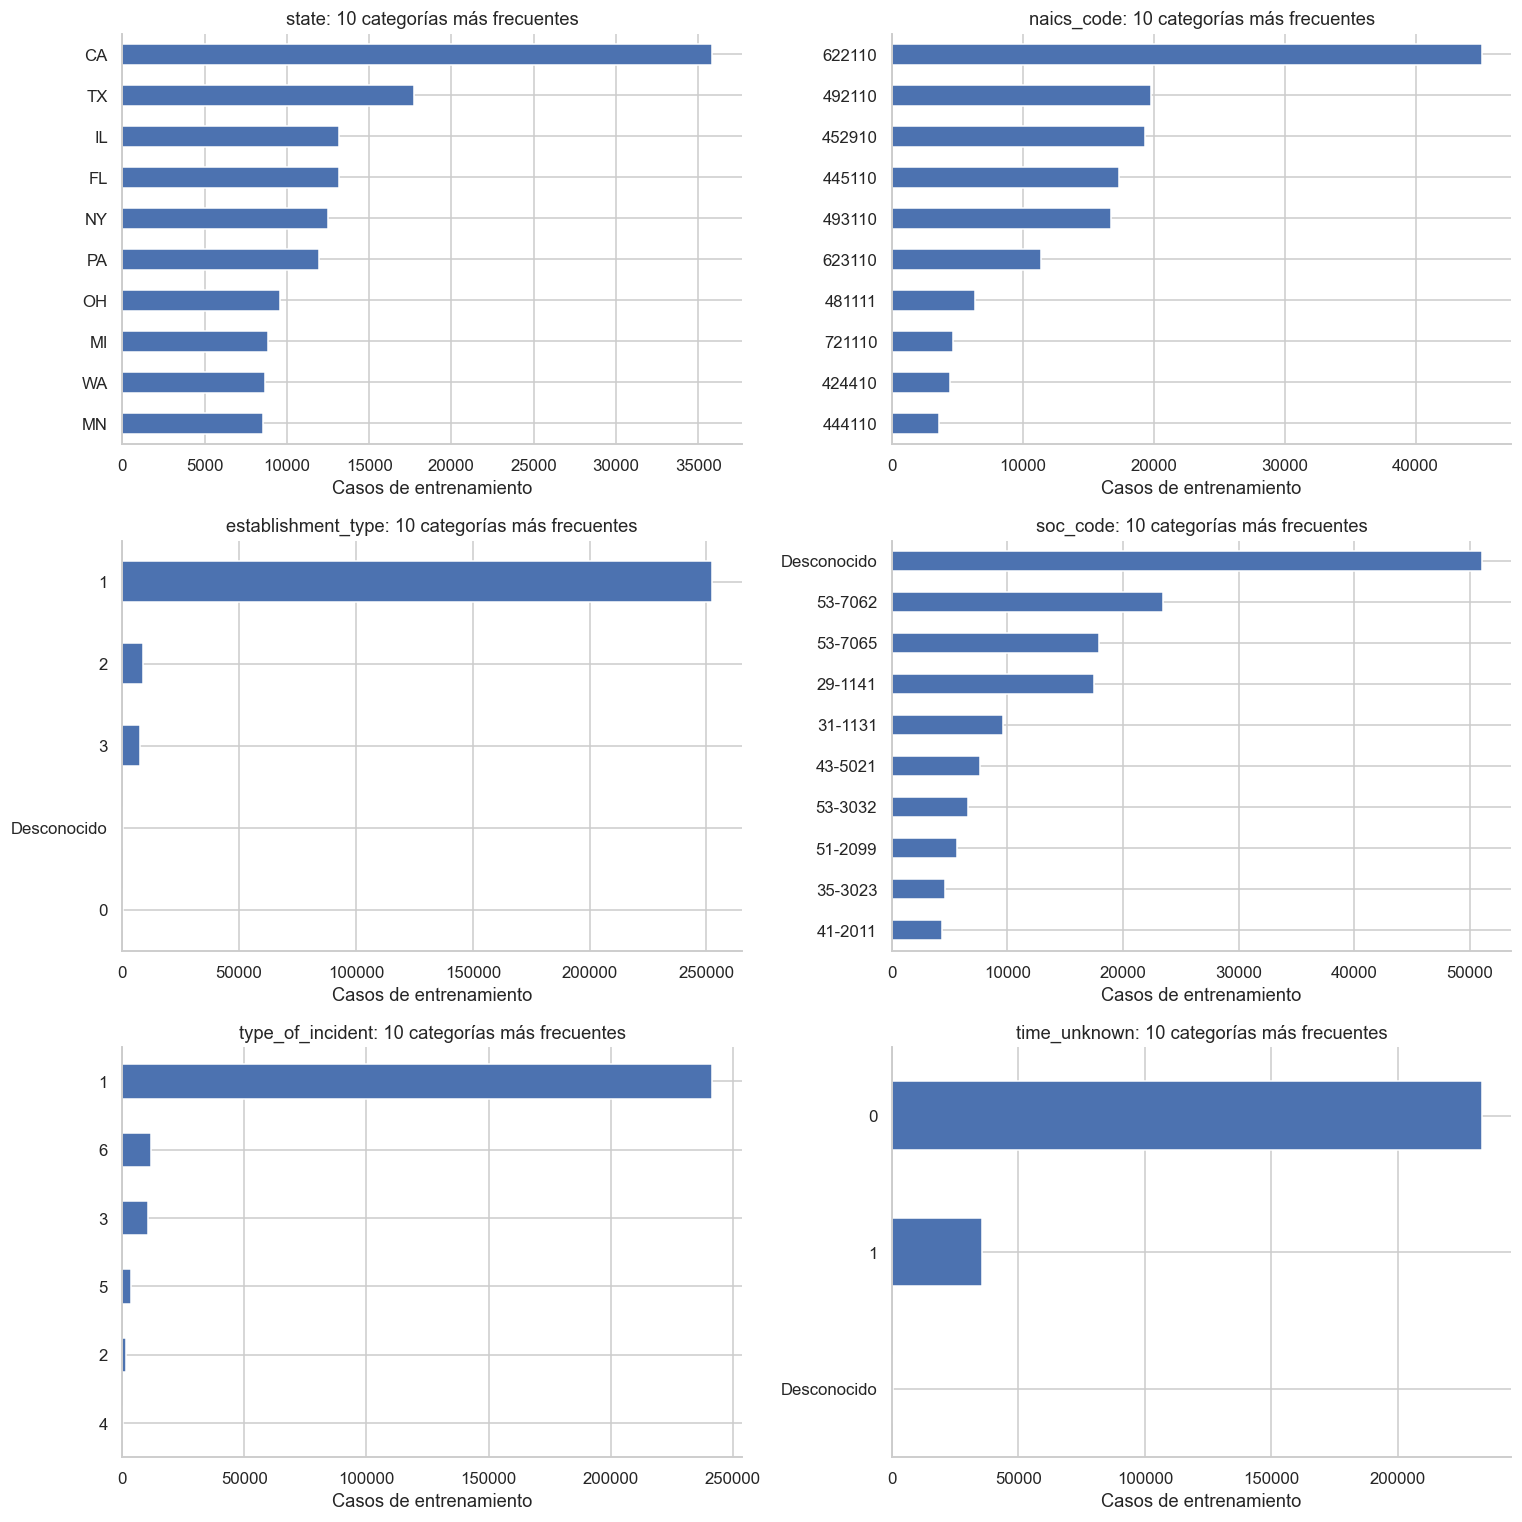

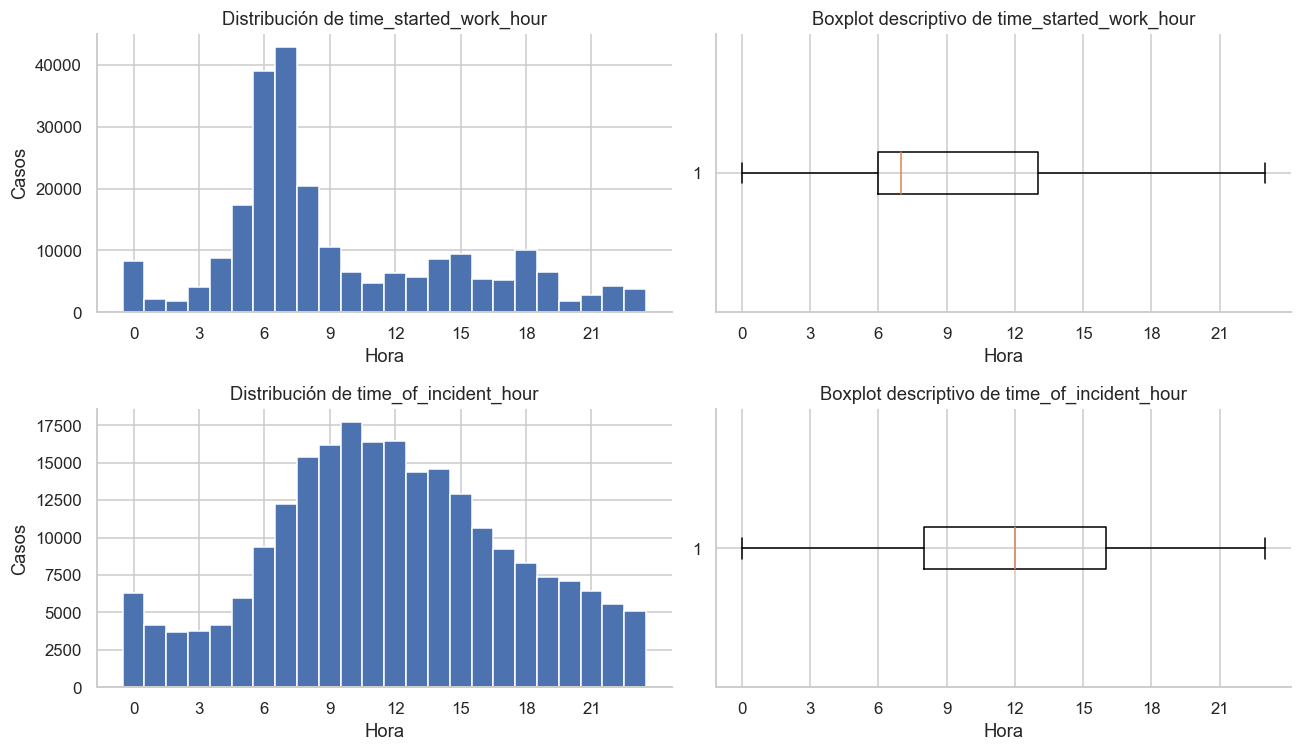

Industria y ocupación son códigos nominales de alta cardinalidad. Se codifican con one-hot; sus números no se interpretan como magnitudes. Las horas se representan como categorías para evitar una relación lineal impuesta entre hora y resultado. Los boxplots son descriptivos: valores horarios válidos no se eliminan por IQR.

In [6]:
# Resumen unidimensional compacto de los ocho predictores
categorical_predictors = baseline['features'][:6]
hour_predictors = baseline['features'][6:]

univariate_rows = []
for c in categorical_predictors:
    s = feature_view[c].astype('object').fillna('Desconocido')
    counts = s.value_counts(dropna=False)
    rare_mask = (counts / len(s)) < 0.01
    univariate_rows.append({
        'Variable': c,
        'Tipo': 'Categórica',
        'Cardinalidad': int(s.nunique(dropna=False)),
        'Faltantes (%)': 100 * feature_view[c].isna().mean(),
        'Categoría más frecuente': str(counts.index[0]),
        'Frecuencia máxima (%)': 100 * counts.iloc[0] / len(s),
        'Categorías < 1 %': int(rare_mask.sum()),
        'Casos en categorías < 1 % (%)': 100 * counts.loc[rare_mask].sum() / len(s)
    })

for c in hour_predictors:
    s = pd.to_numeric(feature_view[c], errors='coerce')
    counts = s.value_counts(dropna=True)
    univariate_rows.append({
        'Variable': c,
        'Tipo': 'Hora discreta (0–23)',
        'Cardinalidad': int(s.nunique(dropna=True)),
        'Faltantes (%)': 100 * s.isna().mean(),
        'Categoría más frecuente': str(counts.index[0]) if len(counts) else 'NA',
        'Frecuencia máxima (%)': 100 * counts.iloc[0] / len(s) if len(counts) else np.nan,
        'Categorías < 1 %': np.nan,
        'Casos en categorías < 1 % (%)': np.nan
    })

display(pd.DataFrame(univariate_rows))

fig, axes = plt.subplots(3, 2, figsize=(14, 14))
for ax, c in zip(axes.flat, categorical_predictors):
    s = feature_view[c].astype('object').fillna('Desconocido')
    counts = s.value_counts().head(10).iloc[::-1]
    counts.plot.barh(ax=ax)
    ax.set(title=f'{c}: 10 categorías más frecuentes',
           xlabel='Casos de entrenamiento', ylabel='')
plt.tight_layout()
plt.show()

fig, axes = plt.subplots(2, 2, figsize=(12, 7))
for j, c in enumerate(hour_predictors):
    s = pd.to_numeric(feature_view[c], errors='coerce').dropna()
    axes[j, 0].hist(s, bins=np.arange(-0.5, 24.5, 1))
    axes[j, 0].set(title=f'Distribución de {c}', xlabel='Hora', ylabel='Casos',
                   xticks=range(0, 24, 3))
    axes[j, 1].boxplot(s, vert=False)
    axes[j, 1].set(title=f'Boxplot descriptivo de {c}', xlabel='Hora',
                   xticks=range(0, 24, 3))
plt.tight_layout()
plt.show()

display(Markdown('Industria y ocupación son códigos nominales de alta cardinalidad. Se codifican con one-hot; sus números no se interpretan como magnitudes. Las horas se representan como categorías para evitar una relación lineal impuesta entre hora y resultado. Los boxplots son descriptivos: valores horarios válidos no se eliminan por IQR.'))


### 5.2 Patrón y mecanismo de valores faltantes

El enunciado solicita distinguir MCAR, MAR y MNAR. Con estos datos observacionales no es posible demostrar el mecanismo de ausencia solo a partir del CSV. Sin embargo, se puede evaluar si la ausencia se relaciona con variables observadas.

La matriz siguiente visualiza una muestra aleatoria únicamente para mostrar **patrones de ausencia**; los porcentajes y cálculos continúan usando todo el entrenamiento. La concentración de faltantes por resultado y por variable contradice una lectura ingenua de “faltantes completamente al azar”. En consecuencia, el proyecto trata la imputación como parte del `Pipeline` y conserva explícitamente la incertidumbre sobre el mecanismo.


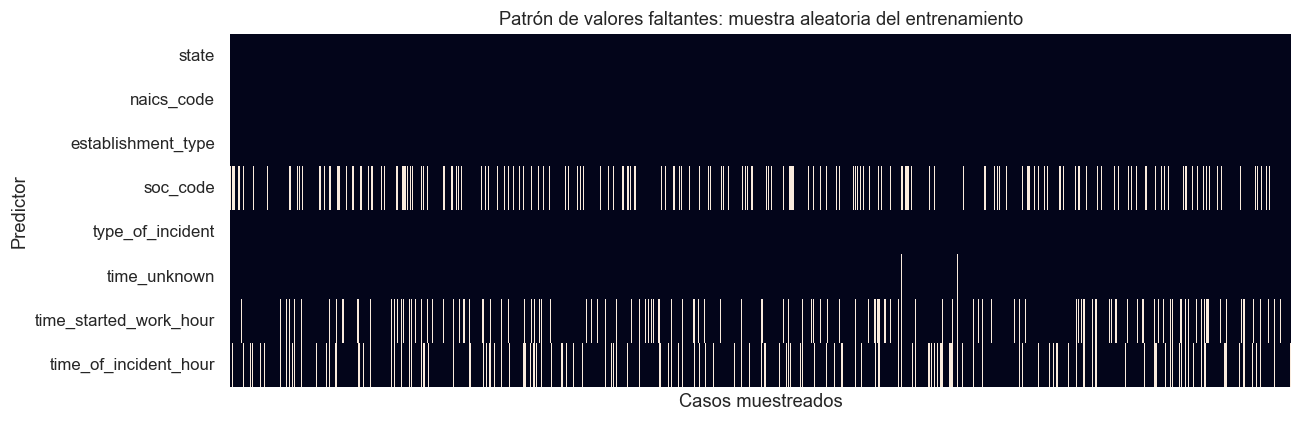

,state,naics_code,establishment_type,soc_code,type_of_incident,time_unknown,time_started_work_hour,time_of_incident_hour
Resultado,,,,,,,,
Fallecimiento (Death),0.000,0.000,0.000,15.942,0.000,0.000,13.043,13.043
Días de ausencia,0.000,0.000,0.067,17.746,0.000,0.206,12.964,16.201
Traslado / restricción,0.000,0.000,0.114,18.659,0.000,0.162,10.099,9.747
Otro caso registrable,0.000,0.000,0.166,20.486,0.000,0.242,13.367,13.718


In [7]:
missing_matrix = feature_view.isna()
missing_sample = missing_matrix.sample(n=min(3000, len(missing_matrix)), random_state=42)

fig, ax = plt.subplots(figsize=(12, 4))
sns.heatmap(missing_sample.T, cbar=False, yticklabels=True, xticklabels=False, ax=ax)
ax.set(title='Patrón de valores faltantes: muestra aleatoria del entrenamiento',
       xlabel='Casos muestreados', ylabel='Predictor')
plt.tight_layout()
plt.show()

display(
    missing_matrix.groupby(train.outcome)
    .mean()
    .mul(100)
    .reindex(OUTCOMES.values())
    .rename_axis('Resultado')
)


## 6. Distribución del resultado y del tipo de incidente


,Casos,Porcentaje
Fallecimiento (Death),69,0.026
Días de ausencia,99697,36.991
Traslado / restricción,79848,29.626
Otro caso registrable,89902,33.357


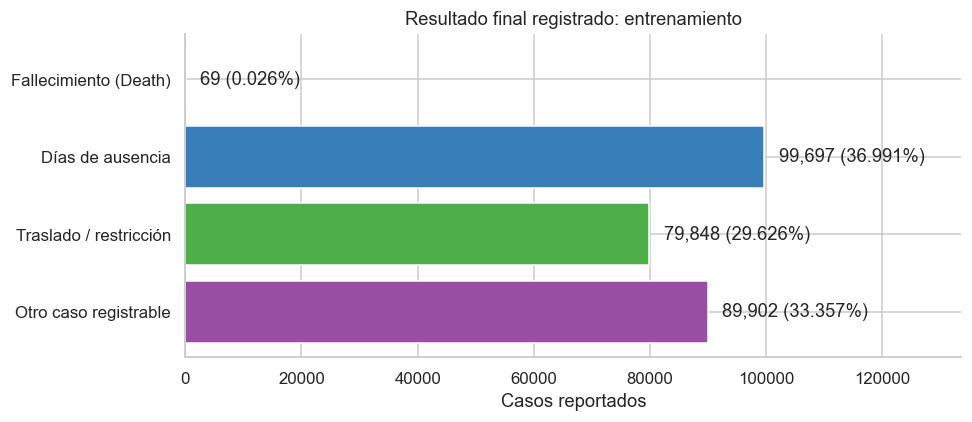

,Casos,Porcentaje
Lesión,241682,89.673
Otra enfermedad,11869,4.404
Afección respiratoria,10497,3.895
Pérdida auditiva,3772,1.400
Trastorno cutáneo,1412,0.524
Intoxicación,284,0.105


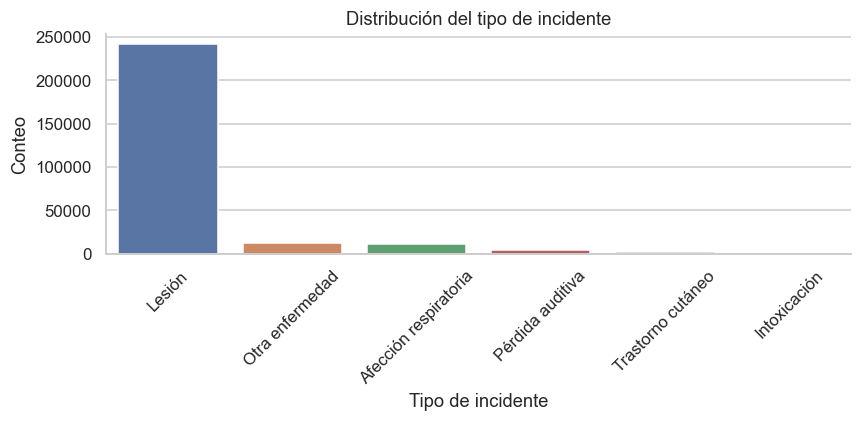

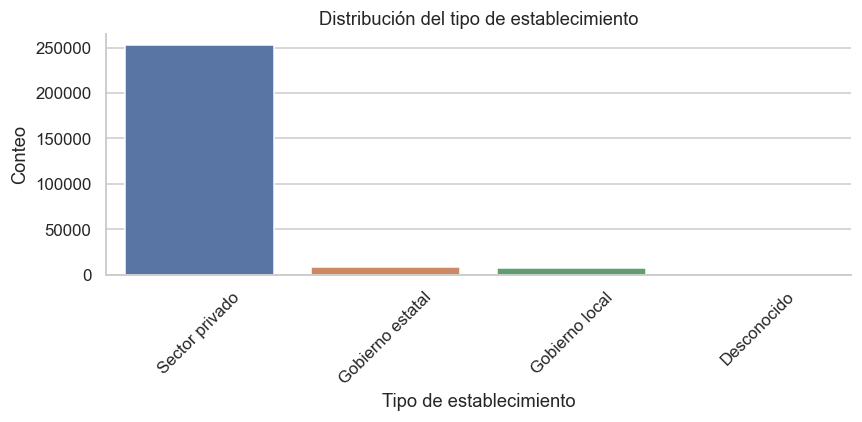

El desarrollo contiene **69 fallecimientos** entre **269,516 casos**. Esta rareza exige métricas por clase y precisión–sensibilidad; la exactitud global puede ocultar fallos en Death. No se agrupan resultados para mejorar puntuaciones.

In [8]:
def count_table(series):
    t = series.fillna('Desconocido').value_counts().rename('cases').to_frame()
    t['percent'] = 100*t.cases/len(series)
    return t

target_counts = train.outcome.value_counts().reindex(OUTCOMES.values()).rename('cases').to_frame()
target_counts['percent'] = target_counts.cases/len(train)*100
display(target_counts)
fig, ax = plt.subplots(figsize=(9,4))
ax.barh(target_counts.index, target_counts.cases, color=['#b2182b','#377eb8','#4daf4a','#984ea3'])
for i, row in enumerate(target_counts.itertuples()):
    ax.text(row.cases+2500, i, f'{row.cases:,} ({row.percent:.3f}%)', va='center')
ax.set(xlabel='Casos reportados', ylabel='', title='Resultado final registrado: entrenamiento', xlim=(0,target_counts.cases.max()*1.34))
ax.invert_yaxis(); plt.tight_layout(); plt.show()
display(count_table(train.incident_type))
eda.plot_categorical_distributions(train, ['incident_type','establishment_type_label'], max_categories=10)

display(Markdown(f'El desarrollo contiene **{int(train[TARGET].eq(1).sum())} fallecimientos** entre **{len(train):,} casos**. Esta rareza exige métricas por clase y precisión–sensibilidad; la exactitud global puede ocultar fallos en Death. No se agrupan resultados para mejorar puntuaciones.'))


Death es una clase pequeña y sustantivamente distinta. La exactitud global puede ocultar un desempeño deficiente en ella. La exactitud balanceada (promedio de sensibilidad por clase), F1 macro y las métricas por clase deben complementar la exactitud. No se interpretan los códigos como una escala de gravedad de cuatro puntos ni se agrupan clases para mejorar las puntuaciones.


## 7. Industria, ocupación y distribución geográfica


,Casos,Porcentaje
Salud / asistencia social,70802,26.270
Transporte / almacenamiento,57429,21.308
Comercio minorista,50979,18.915
Manufactura,49857,18.499
Comercio mayorista,11749,4.359
Alojamiento / alimentación,6709,2.489
Administración pública,4436,1.646
Arte / recreación,4382,1.626
Agricultura / silvicultura,3906,1.449
Construcción,3183,1.181


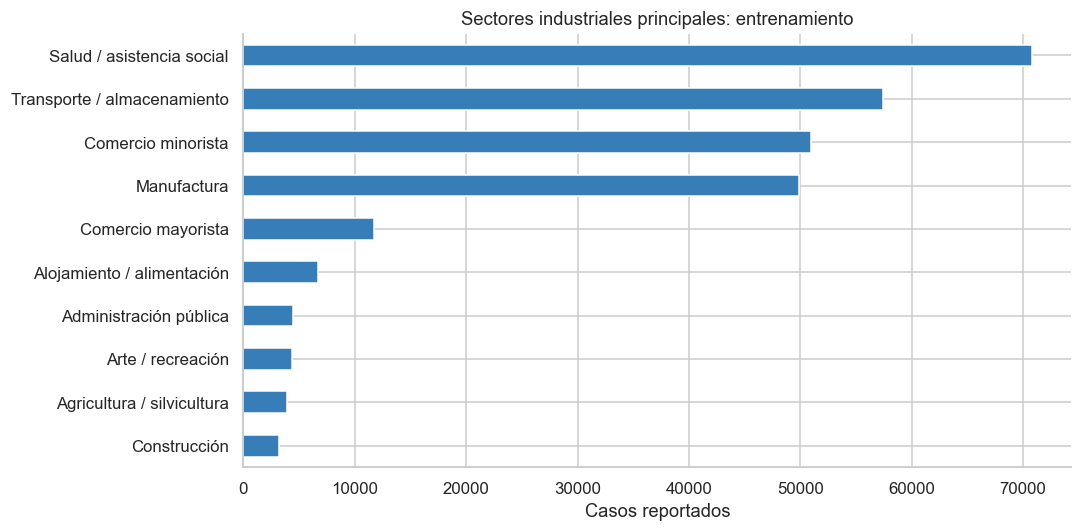

,Casos,Porcentaje
Sin codificar,51019,18.930
Trabajadores de carga y movimiento manual de materiales,23444,8.699
Reponedores y preparadores de pedidos,17915,6.647
Profesionales de enfermería,17451,6.475
Auxiliares de enfermería,9579,3.554
Mensajeros,7659,2.842
Conductores de camiones pesados y tractocamiones,6621,2.457
Otros ensambladores y fabricantes,5949,2.207
Trabajadores de comida rápida y mostrador,4627,1.717
Cajeros,4301,1.596


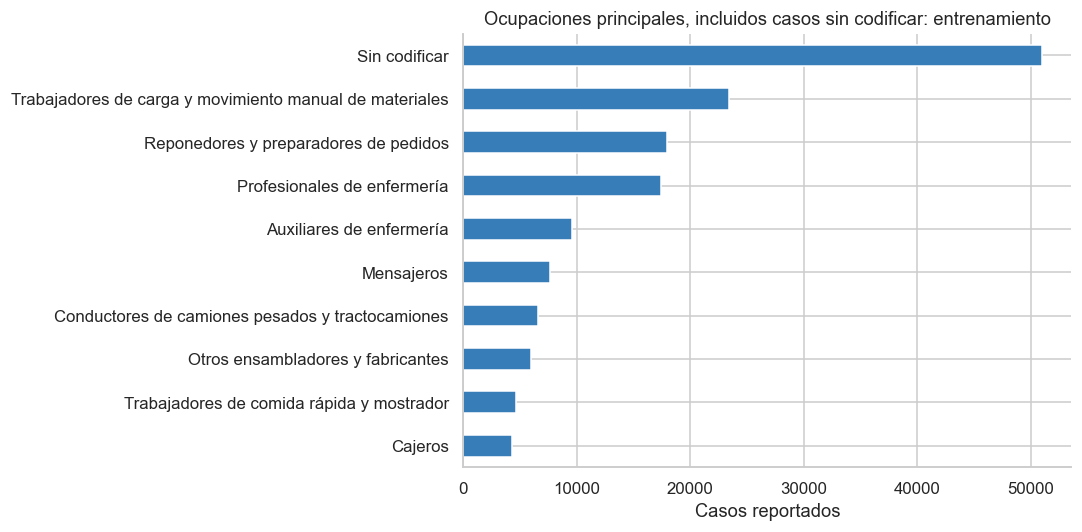

,Casos,Porcentaje
CA,35858,13.305
TX,17717,6.574
IL,13177,4.889
FL,13145,4.877
NY,12483,4.632
PA,11955,4.436
OH,9592,3.559
MI,8858,3.287
WA,8693,3.225
MN,8559,3.176


Códigos NAICS distintos: 715 | ocupaciones codificadas: 598 | códigos de estado/territorio: 55
Filas sin sector industrial reconocido: 45


In [9]:
def top_categories(series, title, n=10):
    table = count_table(series)
    display(table.head(n))
    shown = table.head(n).iloc[::-1]
    fig, ax = plt.subplots(figsize=(10,5))
    shown.cases.plot.barh(ax=ax, color='#377eb8')
    ax.set(title=title, xlabel='Casos reportados', ylabel='')
    plt.tight_layout(); plt.show()
    return table

industry_counts = top_categories(train.industry_sector, 'Sectores industriales principales: entrenamiento')
occupation_counts = top_categories(train.soc_description, 'Ocupaciones principales, incluidos casos sin codificar: entrenamiento')
state_counts = count_table(train.state)
display(state_counts.head(10))
print('Códigos NAICS distintos:', train.naics_code.nunique(), '| ocupaciones codificadas:', train.soc_code.nunique(), '| códigos de estado/territorio:', train.state.nunique())
print('Filas sin sector industrial reconocido:', int(train.industry_sector.eq('Código sin correspondencia').sum()))


Se muestran **proporciones de casos reportados**, no tasas de lesiones ni clasificaciones de riesgo industrial. El tamaño del establecimiento, las horas de exposición, los criterios de cobertura y las prácticas de reporte afectan los conteos. Industria y ocupación están relacionadas y pueden aportar información redundante. Las versiones de los códigos y los valores no reconocidos requieren una auditoría posterior del diccionario; no se les asigna un significado supuesto.


## 8. Relaciones entre predictores y resultado multiclase


incident_outcome,Fallecimiento (Death),Días de ausencia,Traslado / restricción,Otro caso registrable,Total de casos
Salud / asistencia social,2,25373,12400,33027,70802
Transporte / almacenamiento,13,25875,22986,8555,57429
Comercio minorista,3,18569,12353,20054,50979
Manufactura,23,14784,18613,16437,49857
Comercio mayorista,5,4812,4714,2218,11749
Alojamiento / alimentación,4,2604,2074,2027,6709
Administración pública,3,1743,790,1900,4436
Arte / recreación,0,1249,1984,1149,4382
Agricultura / silvicultura,4,1387,1223,1292,3906
Construcción,7,1149,1005,1022,3183


,Fallecimiento (Death),Días de ausencia,Traslado / restricción,Otro caso registrable
Salud / asistencia social,0.003,35.837,17.514,46.647
Transporte / almacenamiento,0.023,45.056,40.025,14.897
Comercio minorista,0.006,36.425,24.232,39.338
Manufactura,0.046,29.653,37.333,32.968
Comercio mayorista,0.043,40.957,40.123,18.878
Alojamiento / alimentación,0.060,38.814,30.914,30.213
Administración pública,0.068,39.292,17.809,42.831
Arte / recreación,0.000,28.503,45.276,26.221
Agricultura / silvicultura,0.102,35.509,31.311,33.077
Construcción,0.220,36.098,31.574,32.108


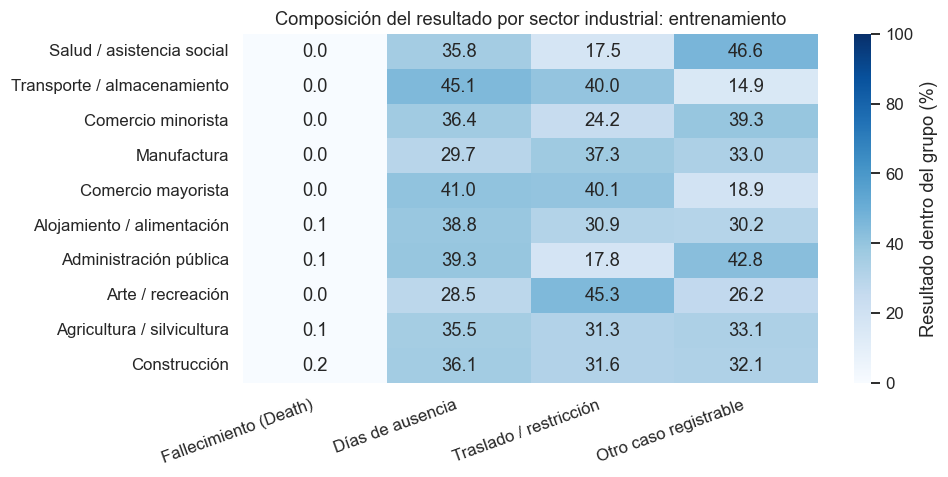

incident_outcome,Fallecimiento (Death),Días de ausencia,Traslado / restricción,Otro caso registrable,Total de casos
incident_type,,,,,
Lesión,55,85122,75600,80905,241682
Trastorno cutáneo,0,585,181,646,1412
Afección respiratoria,3,9636,119,739,10497
Intoxicación,0,86,56,142,284
Pérdida auditiva,0,382,342,3048,3772
Otra enfermedad,11,3886,3550,4422,11869


,Fallecimiento (Death),Días de ausencia,Traslado / restricción,Otro caso registrable
incident_type,,,,
Lesión,0.023,35.221,31.281,33.476
Trastorno cutáneo,0.000,41.431,12.819,45.751
Afección respiratoria,0.029,91.798,1.134,7.040
Intoxicación,0.000,30.282,19.718,50.000
Pérdida auditiva,0.000,10.127,9.067,80.806
Otra enfermedad,0.093,32.741,29.910,37.257


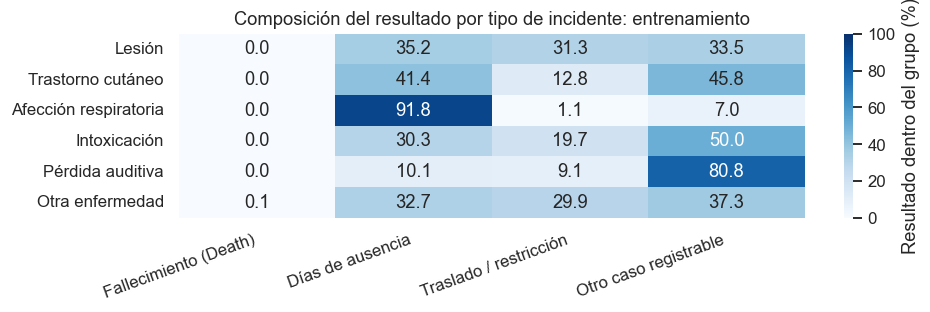

incident_outcome,Fallecimiento (Death),Días de ausencia,Traslado / restricción,Otro caso registrable,Total de casos
Sin codificar,11,17692,14899,18417,51019
Trabajadores de carga y movimiento manual de materiales,1,9017,9785,4641,23444
Reponedores y preparadores de pedidos,1,5163,9191,3560,17915
Profesionales de enfermería,0,4828,2402,10221,17451
Auxiliares de enfermería,0,4714,2436,2429,9579
Mensajeros,0,4144,2141,1374,7659
Conductores de camiones pesados y tractocamiones,10,3340,2009,1262,6621
Otros ensambladores y fabricantes,1,1962,2254,1732,5949


,Fallecimiento (Death),Días de ausencia,Traslado / restricción,Otro caso registrable
Sin codificar,0.022,34.677,29.203,36.098
Trabajadores de carga y movimiento manual de materiales,0.004,38.462,41.738,19.796
Reponedores y preparadores de pedidos,0.006,28.819,51.303,19.872
Profesionales de enfermería,0.000,27.666,13.764,58.570
Auxiliares de enfermería,0.000,49.212,25.431,25.358
Mensajeros,0.000,54.106,27.954,17.940
Conductores de camiones pesados y tractocamiones,0.151,50.446,30.343,19.061
Otros ensambladores y fabricantes,0.017,32.980,37.889,29.114


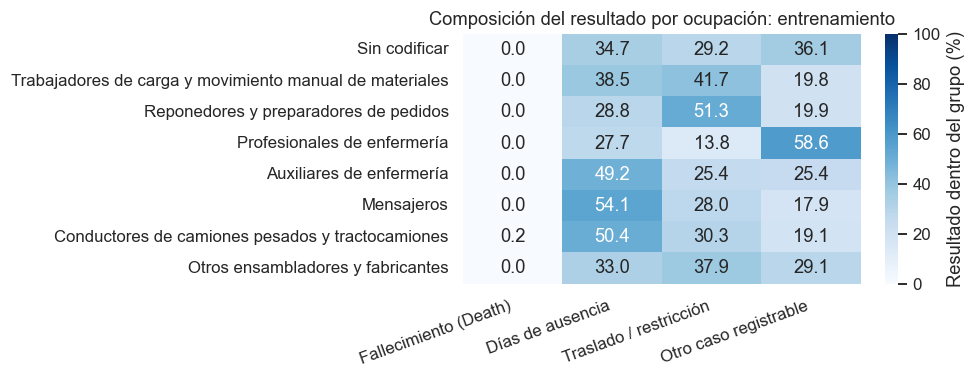

Las composiciones mostradas utilizan casos reportados dentro de cada grupo. Las diferencias pueden reflejar mezcla ocupacional, diagnósticos y prácticas de reporte. Sin trabajadores u horas expuestos como denominador, no son probabilidades de lesión.

In [10]:
def outcome_comparison(column, title, levels=None):
    levels = levels if levels is not None else train[column].fillna('Desconocido').value_counts().head(10).index
    counts = pd.crosstab(train[column].fillna('Desconocido'), train[TARGET]).reindex(index=levels, columns=list(OUTCOMES), fill_value=0)
    proportions = counts.div(counts.sum(axis=1),axis=0)*100
    proportions.columns = [OUTCOMES[c] for c in proportions.columns]
    display(counts.rename(columns=OUTCOMES).assign(total_cases=counts.sum(axis=1)))
    display(proportions)
    fig, ax = plt.subplots(figsize=(9,max(3,len(levels)*0.45)))
    sns.heatmap(proportions, annot=True, fmt='.1f', cmap='Blues', vmin=0, vmax=100, ax=ax, cbar_kws={'label':'Resultado dentro del grupo (%)'})
    ax.set(title=title, xlabel='', ylabel='')
    plt.xticks(rotation=20, ha='right'); plt.tight_layout(); plt.show()
    return proportions

industry_outcomes = outcome_comparison('industry_sector', 'Composición del resultado por sector industrial: entrenamiento')
incident_outcomes = outcome_comparison('incident_type', 'Composición del resultado por tipo de incidente: entrenamiento', list(INCIDENTS.values()))
occupation_outcomes = outcome_comparison('soc_description', 'Composición del resultado por ocupación: entrenamiento', occupation_counts.head(8).index)

display(Markdown('Las composiciones mostradas utilizan casos reportados dentro de cada grupo. Las diferencias pueden reflejar mezcla ocupacional, diagnósticos y prácticas de reporte. Sin trabajadores u horas expuestos como denominador, no son probabilidades de lesión.'))


Los denominadores son los casos de cada grupo. Las tablas conservan los conteos de fallecimientos porque un mapa de porcentajes puede ocultar esta clase infrecuente. Las comparaciones son descriptivas y no están ajustadas por composición industria–ocupación, prácticas de los empleadores u otros factores. La dependencia dentro de establecimientos invalida una interpretación ingenua de pruebas basadas en filas independientes; los valores p clásicos que aparecen después son ilustraciones bajo un supuesto de independencia incumplido, no inferencia válida para estos datos. Bonferroni controla multiplicidad solo bajo los supuestos de cada prueba y no repara esta dependencia. Las decisiones se apoyan en magnitudes descriptivas y procedencia, no en significancia.



### 8.1 Asociación entre predictores y variable objetivo

Para los predictores categóricos se reporta **χ²** y **V de Cramér**. Debido a que hay cientos de miles de filas y dependencia dentro de establecimientos, los valores p pueden ser extremadamente pequeños incluso para asociaciones modestas; por ello, **V de Cramér es la medida principal de magnitud**. Los valores p se muestran como referencia descriptiva y se ajustan con Bonferroni.

También se reporta **información mutua normalizada (NMI)** como medida no lineal. Las horas se discretizan por hora del día para este cálculo. Para las dos variables horarias se añade Kruskal–Wallis y un tamaño de efecto aproximado ε². Ninguno de estos análisis implica causalidad.


,Predictor,Tipo de análisis,V de Cramér,NMI,p-valor χ²,Grados de libertad,p ajustado Bonferroni
1,naics_code,χ² / V de Cramér,0.236,0.033,0.000,2142,0.000
3,soc_code,χ² / V de Cramér,0.206,0.025,0.000,1794,0.000
4,type_of_incident,χ² / V de Cramér,0.150,0.045,0.000,15,0.000
0,state,χ² / V de Cramér,0.121,0.010,0.000,162,0.000
2,establishment_type,χ² / V de Cramér,0.056,0.007,0.000,12,0.000
5,time_unknown,χ² / V de Cramér,0.055,0.004,0.000,6,0.000


,Predictor,H de Kruskal–Wallis,p-valor,ε² aproximado,NMI (hora discretizada),Casos utilizables,p ajustado Bonferroni
0,time_started_work_hour,2.068,0.558,0.000,0.004,236501,1.000
1,time_of_incident_hour,88.191,0.000,0.000,0.002,233239,0.000


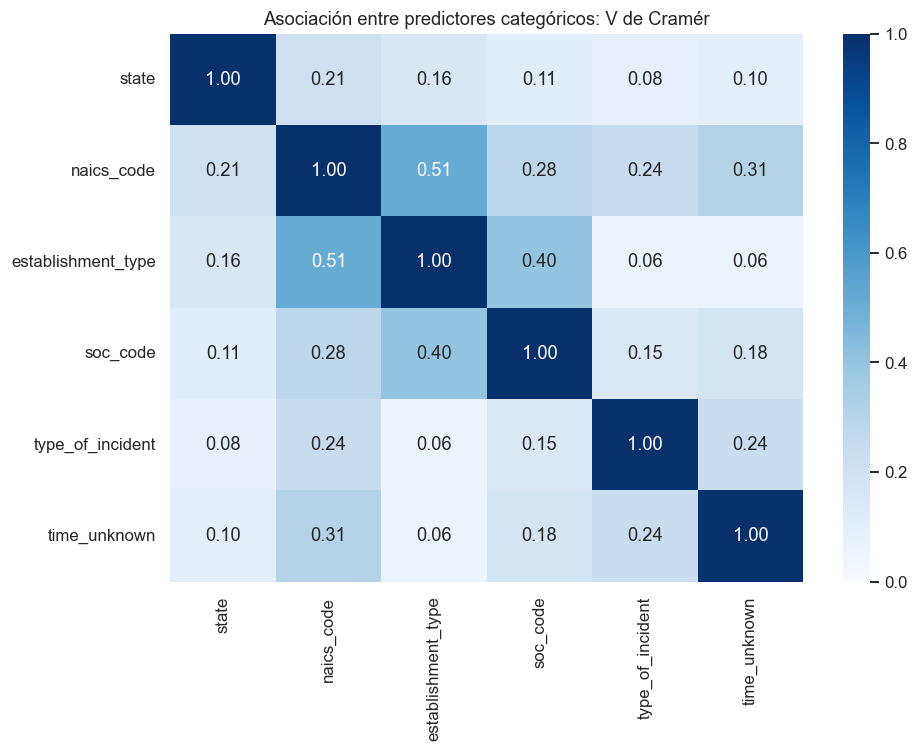

Diagnóstico univariable: state newton-cg verificado: True


Diagnóstico univariable: naics_code newton-cg verificado: True


Diagnóstico univariable: establishment_type newton-cg verificado: True


Diagnóstico univariable: soc_code newton-cg verificado: True


Diagnóstico univariable: type_of_incident newton-cg verificado: True


...

Diagnóstico univariable: time_of_incident_hour newton-cg verificado: True


,Predictor,AUC macro OvR en agosto–septiembre,Solver final,Iteraciones,Verificado
0,state,0.512,newton-cg,22,True
1,naics_code,0.629,newton-cg,22,True
2,establishment_type,0.515,newton-cg,15,True
3,soc_code,0.618,newton-cg,22,True
4,type_of_incident,0.572,newton-cg,18,True
5,time_unknown,0.499,newton-cg,14,True
6,time_started_work_hour,0.517,newton-cg,22,True
7,time_of_incident_hour,0.517,newton-cg,21,True


,Predictor,solver,iterations,warnings,numerically_verified
0,state,newton-cg,22,[],True
1,naics_code,newton-cg,22,[],True
2,establishment_type,newton-cg,15,[],True
3,soc_code,newton-cg,22,[],True
4,type_of_incident,newton-cg,18,[],True
5,time_unknown,newton-cg,14,[],True
6,time_started_work_hour,newton-cg,22,[],True
7,time_of_incident_hour,newton-cg,21,[],True


Estos ajustes univariables son diagnósticos de fuga dentro del desarrollo; no seleccionan variables ni hiperparámetros. Una asociación fuerte exige examinar disponibilidad y procedencia, no demuestra fuga por sí sola.

La mayor asociación categórica observada corresponde a **naics_code**, con V de Cramér **0.236**. La magnitud y las tablas de composición son más informativas que p-valores de filas dependientes; Bonferroni no corrige la dependencia dentro de establecimientos.

In [11]:
from scipy.stats import chi2_contingency, kruskal
from sklearn.metrics import normalized_mutual_info_score

def cramers_v_bias_corrected(x, y):
    table = pd.crosstab(
        pd.Series(x, copy=False).fillna('Desconocido').astype(str),
        pd.Series(y, copy=False).astype(str)
    )
    chi2, p, dof, _ = chi2_contingency(table, correction=False)
    n = table.to_numpy().sum()
    phi2 = chi2 / n
    r, k = table.shape
    if n <= 1:
        return np.nan, p, dof
    phi2corr = max(0.0, phi2 - ((k - 1) * (r - 1)) / (n - 1))
    rcorr = r - ((r - 1) ** 2) / (n - 1)
    kcorr = k - ((k - 1) ** 2) / (n - 1)
    denom = min(kcorr - 1, rcorr - 1)
    v = np.sqrt(phi2corr / denom) if denom > 0 else 0.0
    return float(v), float(p), int(dof)

association_rows = []
for c in categorical_predictors:
    s = feature_view[c].astype('object').fillna('Desconocido')
    v, p, dof = cramers_v_bias_corrected(s, train[TARGET])
    nmi = normalized_mutual_info_score(s.astype(str), train[TARGET].astype(str))
    association_rows.append({
        'Predictor': c,
        'Tipo de análisis': 'χ² / V de Cramér',
        'V de Cramér': v,
        'NMI': nmi,
        'p-valor χ²': p,
        'Grados de libertad': dof
    })

association_df = pd.DataFrame(association_rows)
association_df['p ajustado Bonferroni'] = np.minimum(
    association_df['p-valor χ²'] * len(association_df), 1.0
)
display(association_df.sort_values('V de Cramér', ascending=False))

hour_rows = []
for c in hour_predictors:
    s = pd.to_numeric(feature_view[c], errors='coerce')
    groups = [s.loc[train[TARGET].eq(label)].dropna().to_numpy() for label in sorted(OUTCOMES)]
    H, p = kruskal(*groups)
    n = sum(len(g) for g in groups)
    k = len(groups)
    epsilon2 = max(0.0, (H - k + 1) / (n - k)) if n > k else np.nan
    hour_as_category = s.round().astype('Int64').astype(str).replace('<NA>', 'Desconocido')
    nmi = normalized_mutual_info_score(hour_as_category, train[TARGET].astype(str))
    hour_rows.append({
        'Predictor': c,
        'H de Kruskal–Wallis': H,
        'p-valor': p,
        'ε² aproximado': epsilon2,
        'NMI (hora discretizada)': nmi,
        'Casos utilizables': n
    })
hour_df=pd.DataFrame(hour_rows)
hour_df['p ajustado Bonferroni']=np.minimum(hour_df['p-valor']*len(hour_df),1.0)
display(hour_df)

pair_vars = list(categorical_predictors)
v_matrix = pd.DataFrame(np.eye(len(pair_vars)), index=pair_vars, columns=pair_vars)
for i, a in enumerate(pair_vars):
    for j in range(i + 1, len(pair_vars)):
        b = pair_vars[j]
        v, _, _ = cramers_v_bias_corrected(
            feature_view[a].astype('object').fillna('Desconocido'),
            feature_view[b].astype('object').fillna('Desconocido')
        )
        v_matrix.loc[a, b] = v_matrix.loc[b, a] = v

fig, ax = plt.subplots(figsize=(9, 7))
sns.heatmap(v_matrix, annot=True, fmt='.2f', vmin=0, vmax=1, cmap='Blues', ax=ax)
ax.set_title('Asociación entre predictores categóricos: V de Cramér')
plt.tight_layout()
plt.show()

from osha_review_checks import single_feature_checks
leak_audit = single_feature_checks(feature_view, train[TARGET], train.incident_date,
                                  PROJECT_DIR/'osha_temporal_results/single_feature_checks.json')
display(pd.DataFrame([{k:v for k,v in row.items() if k != 'Intentos'} for row in leak_audit]))
display(pd.DataFrame([{'Predictor': row['Predictor'], **attempt}
                      for row in leak_audit for attempt in row['Intentos']]))
assert all(row['Verificado'] for row in leak_audit), 'Diagnóstico no convergente; no interpretar su AUC.'

display(Markdown('Estos ajustes univariables son diagnósticos de fuga dentro del desarrollo; no seleccionan variables ni hiperparámetros. Una asociación fuerte exige examinar disponibilidad y procedencia, no demuestra fuga por sí sola.'))

top_association=association_df.sort_values('V de Cramér',ascending=False).iloc[0]
display(Markdown(f'La mayor asociación categórica observada corresponde a **{top_association["Predictor"]}**, con V de Cramér **{top_association["V de Cramér"]:.3f}**. La magnitud y las tablas de composición son más informativas que p-valores de filas dependientes; Bonferroni no corrige la dependencia dentro de establecimientos.'))


### 8.2 Estructura multivariada exploratoria

PCA sobre los códigos NAICS, SOC o estado **no es apropiado**, porque sus números son etiquetas nominales y no magnitudes. Para visualizar una muestra del desarrollo se aplica **TruncatedSVD** a categorías one-hot más horas numéricas imputadas y estandarizadas. Es una representación exploratoria distinta de la del modelo, que codifica también las horas como categorías. Se incluyen todos los fallecimientos y una muestra aleatoria de las demás clases únicamente para hacer visible la clase rara; por tanto, la figura **no representa prevalencias poblacionales** y no se utiliza para seleccionar variables ni para entrenar el modelo.

No se aplica distancia de Mahalanobis sobre los códigos nominales ni se eliminan “outliers multivariados” a partir de distancias arbitrarias en una representación one-hot. Los valores imposibles e inconsistentes se auditan directamente en sus campos originales.


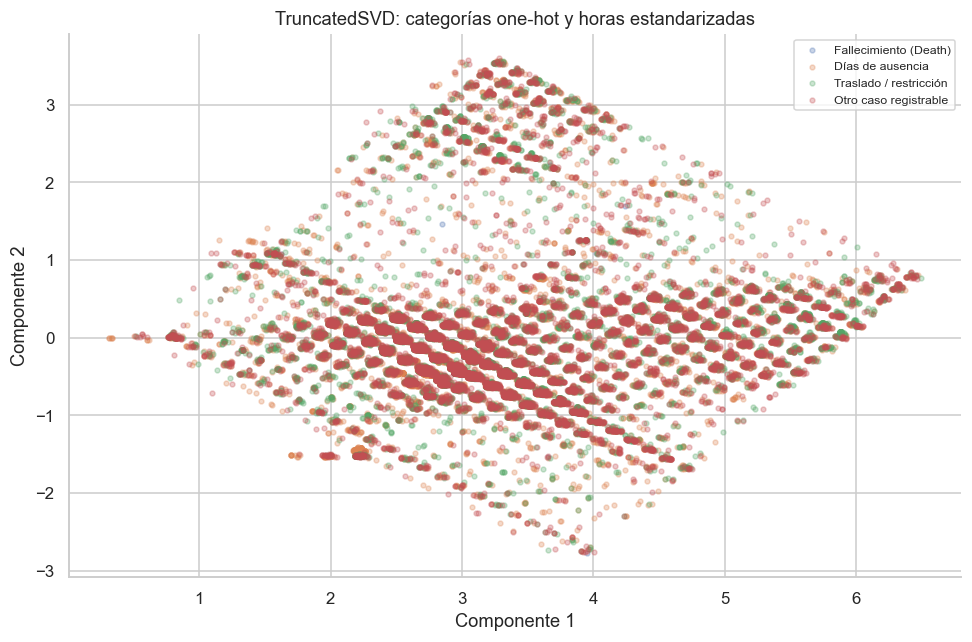

Varianza explicada por los dos componentes: 33.26%
Casos visualizados: 30069 | Death: 69 | otras clases muestreadas: 30000


Los dos componentes explican **33.26 %** de la varianza de esta muestra y representación. Una proyección de dos dimensiones no demuestra separabilidad total, y el sobremuestreo visual de Death impide interpretar densidades como prevalencias.

In [12]:
from sklearn.compose import ColumnTransformer
from sklearn.preprocessing import OneHotEncoder, StandardScaler
from sklearn.impute import SimpleImputer
from sklearn.pipeline import Pipeline
from sklearn.decomposition import TruncatedSVD

death_rows = train.loc[train[TARGET].eq(1)]
nondeath_rows = train.loc[train[TARGET].ne(1)]
nondeath_sample = nondeath_rows.sample(
    n=min(30000, len(nondeath_rows)),
    random_state=42
)
vis = pd.concat([death_rows, nondeath_sample], axis=0)

cat_vis = list(categorical_predictors)
num_vis = list(hour_predictors)
pre_vis = ColumnTransformer(
    transformers=[
        ('cat', Pipeline([
            ('imputer', SimpleImputer(strategy='constant', fill_value='Desconocido')),
            ('onehot', OneHotEncoder(handle_unknown='ignore'))
        ]), cat_vis),
        ('num', Pipeline([
            ('imputer', SimpleImputer(strategy='median')),
            ('scale', StandardScaler(with_mean=False))
        ]), num_vis)
    ],
    sparse_threshold=1.0
)

X_vis = pre_vis.fit_transform(vis[baseline['features']])
svd = TruncatedSVD(n_components=2, random_state=42)
coords = svd.fit_transform(X_vis)

fig, ax = plt.subplots(figsize=(9, 6))
for label in sorted(OUTCOMES):
    mask = vis[TARGET].to_numpy() == label
    ax.scatter(coords[mask, 0], coords[mask, 1], s=10, alpha=0.30, label=OUTCOMES[label])
ax.set(
    title='TruncatedSVD: categorías one-hot y horas estandarizadas',
    xlabel='Componente 1',
    ylabel='Componente 2'
)
ax.legend(fontsize=8)
plt.tight_layout()
plt.show()

print('Varianza explicada por los dos componentes:',
      f'{100 * svd.explained_variance_ratio_.sum():.2f}%')
print('Casos visualizados:', len(vis),
      '| Death:', int(vis[TARGET].eq(1).sum()),
      '| otras clases muestreadas:', int(vis[TARGET].ne(1).sum()))

display(Markdown(f'Los dos componentes explican **{100*svd.explained_variance_ratio_.sum():.2f} %** de la varianza de esta muestra y representación. Una proyección de dos dimensiones no demuestra separabilidad total, y el sobremuestreo visual de Death impide interpretar densidades como prevalencias.'))


## 9. Patrones temporales y precisión del registro


,Fallecimiento (Death),Días de ausencia,Traslado / restricción,Otro caso registrable,Total de casos
incident_date,,,,,
1,9,12806,8741,9642,31198
2,10,11343,8299,9312,28964
3,7,11638,9515,10417,31577
4,10,10224,8367,9561,28162
5,3,10720,9230,10533,30486
6,5,10708,9487,10473,30673
7,7,11267,9510,10707,31491
8,11,12427,9907,11399,33744
9,7,8564,6792,7858,23221


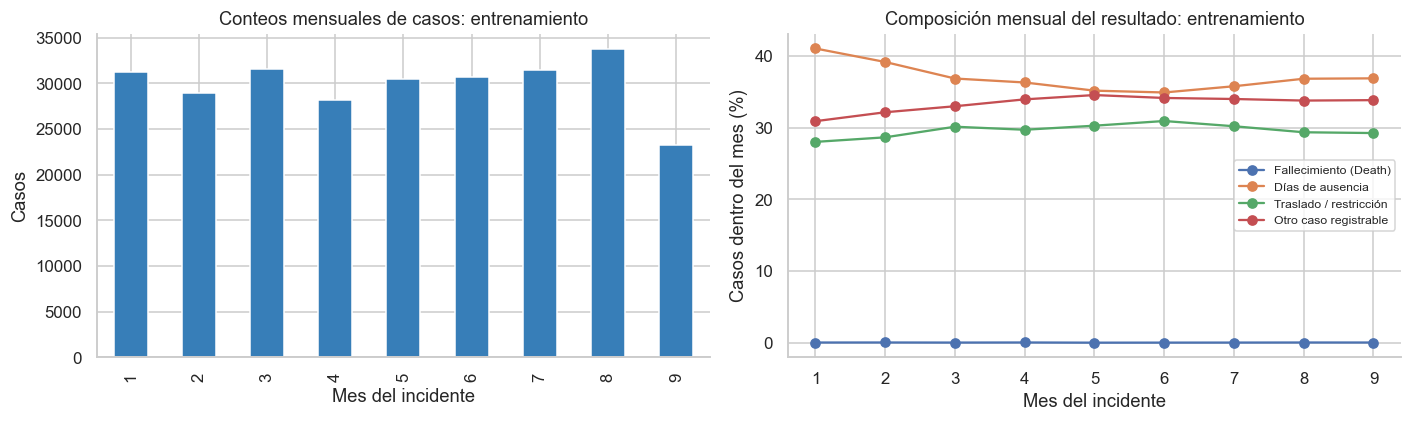

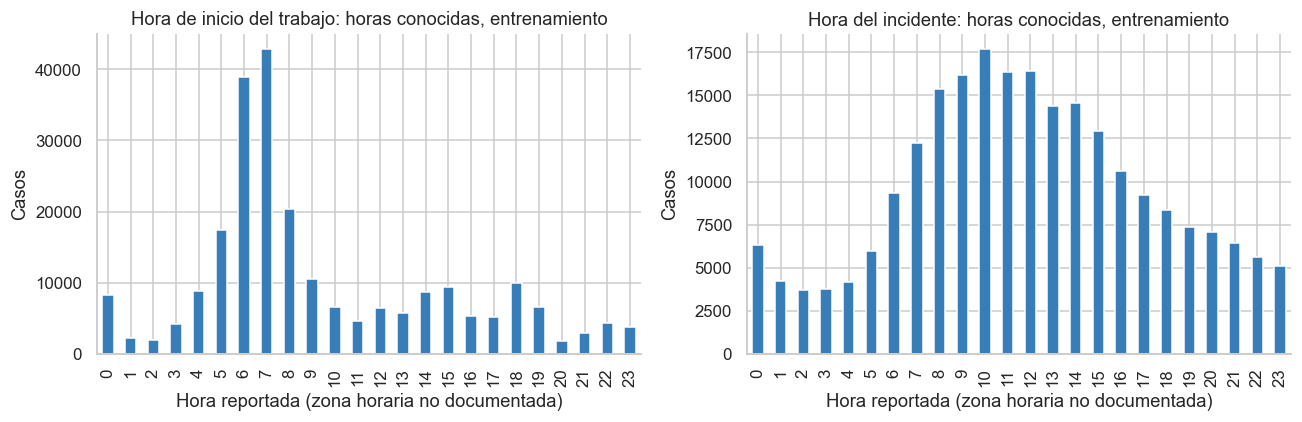

,Registros originales presentes,Minutos iguales a 00,Hora desconocida o no utilizable
time_started_work,236501,149440,33015
time_of_incident,235611,81089,36277


In [13]:
monthly = pd.crosstab(train.incident_date.dt.month, train[TARGET]).reindex(index=range(1,10), columns=list(OUTCOMES), fill_value=0)
monthly.columns = list(OUTCOMES.values())
display(monthly.assign(total_cases=monthly.sum(axis=1)))
fig, axes = plt.subplots(1,2,figsize=(13,4))
monthly.sum(axis=1).plot.bar(ax=axes[0],color='#377eb8')
axes[0].set(title='Conteos mensuales de casos: entrenamiento',xlabel='Mes del incidente',ylabel='Casos')
monthly.div(monthly.sum(axis=1),axis=0).mul(100).plot(ax=axes[1],marker='o')
axes[1].set(title='Composición mensual del resultado: entrenamiento',xlabel='Mes del incidente',ylabel='Casos dentro del mes (%)',xticks=range(1,10))
axes[1].legend(fontsize=8); plt.tight_layout(); plt.show()
fig, axes = plt.subplots(1,2,figsize=(12,4))
for ax,c,label in zip(axes,['time_started_work_hour','time_of_incident_hour'],['Hora de inicio del trabajo','Hora del incidente']):
    counts = train[c].value_counts().reindex(range(24),fill_value=0)
    counts.plot.bar(ax=ax,color='#377eb8')
    ax.set(title=label+': horas conocidas, entrenamiento',xlabel='Hora reportada (zona horaria no documentada)',ylabel='Casos')
plt.tight_layout(); plt.show()
time_audit = {}
for c in ['time_started_work','time_of_incident']:
    raw = train[c].dropna()
    time_audit[c] = {'nonmissing_raw':len(raw), 'minutes_equal_00':int(raw.str.match(r'^\d{1,2}:00:').sum()),
                     'unusable_or_unknown_hour':int(train[c+'_hour'].isna().sum())}
display(pd.DataFrame(time_audit).T)


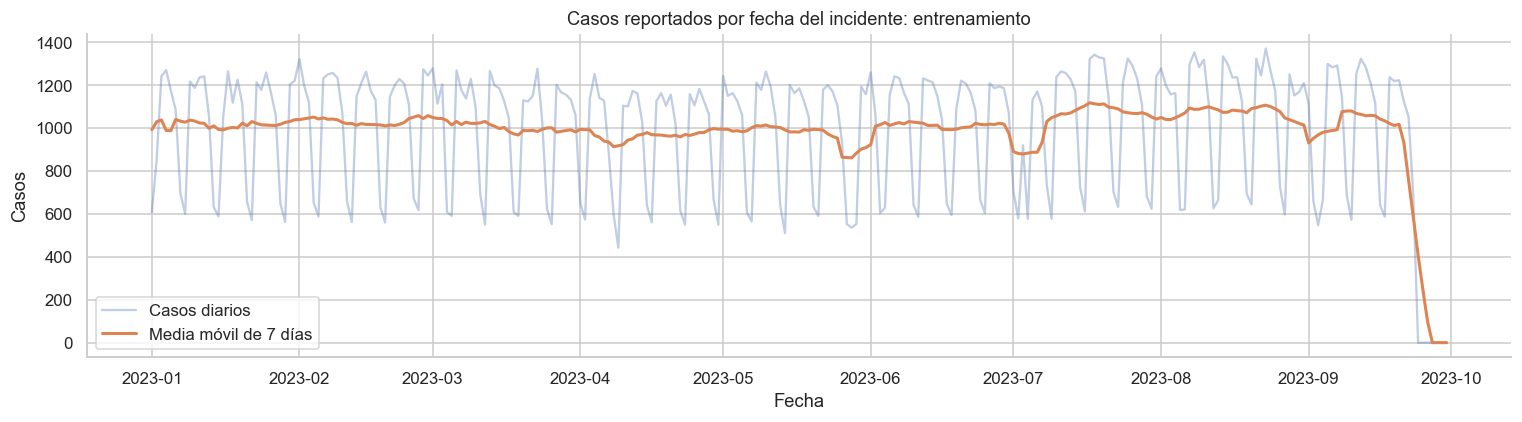

,Fallecimiento (Death),Días de ausencia,Traslado / restricción,Otro caso registrable,Total
Lunes,14,16542,13272,14269,44097
Martes,12,16558,13825,15319,45714
Miércoles,10,16724,14088,15485,46307
Jueves,8,16316,13747,15244,45315
Viernes,13,15064,11946,14145,41168
Sábado,10,9791,6853,8164,24818
Domingo,2,8702,6117,7276,22097


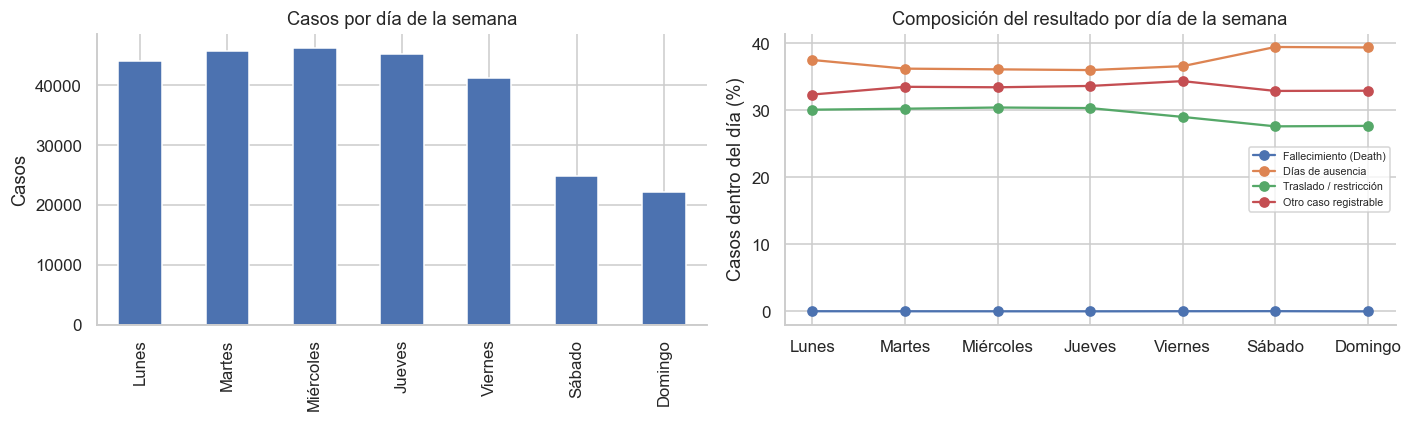

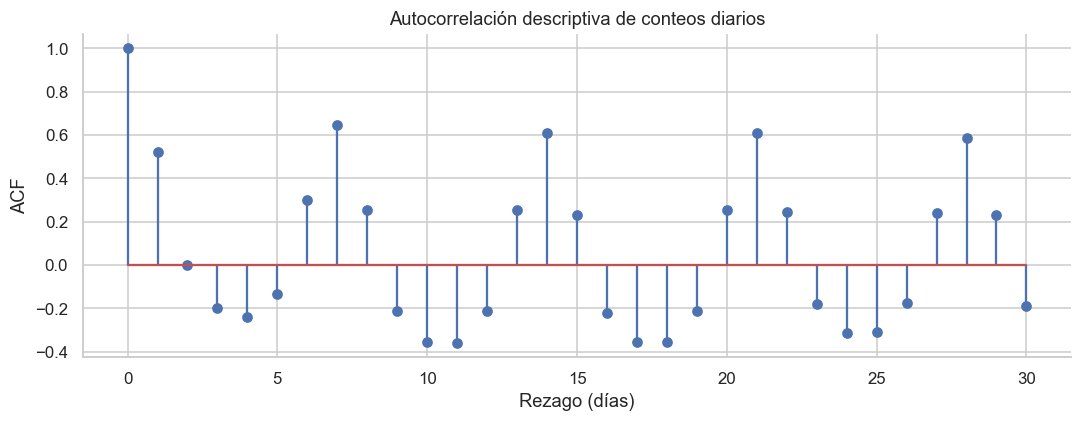

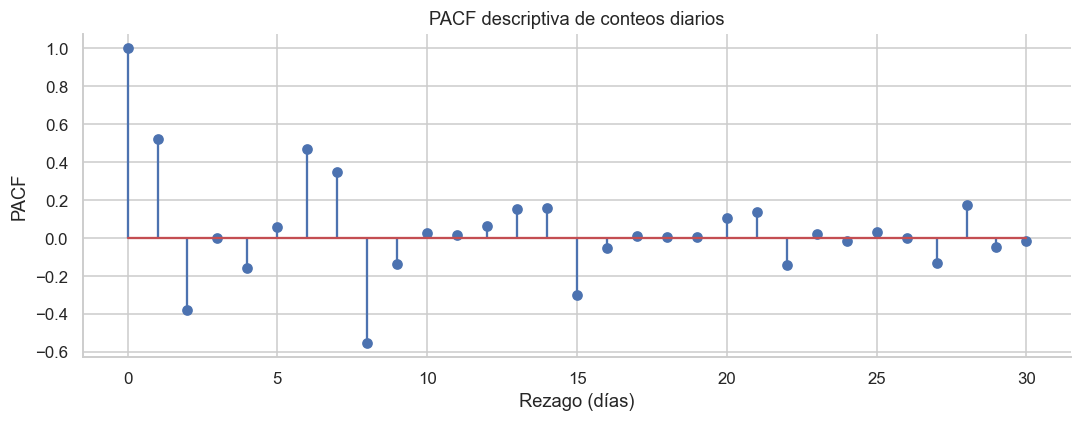

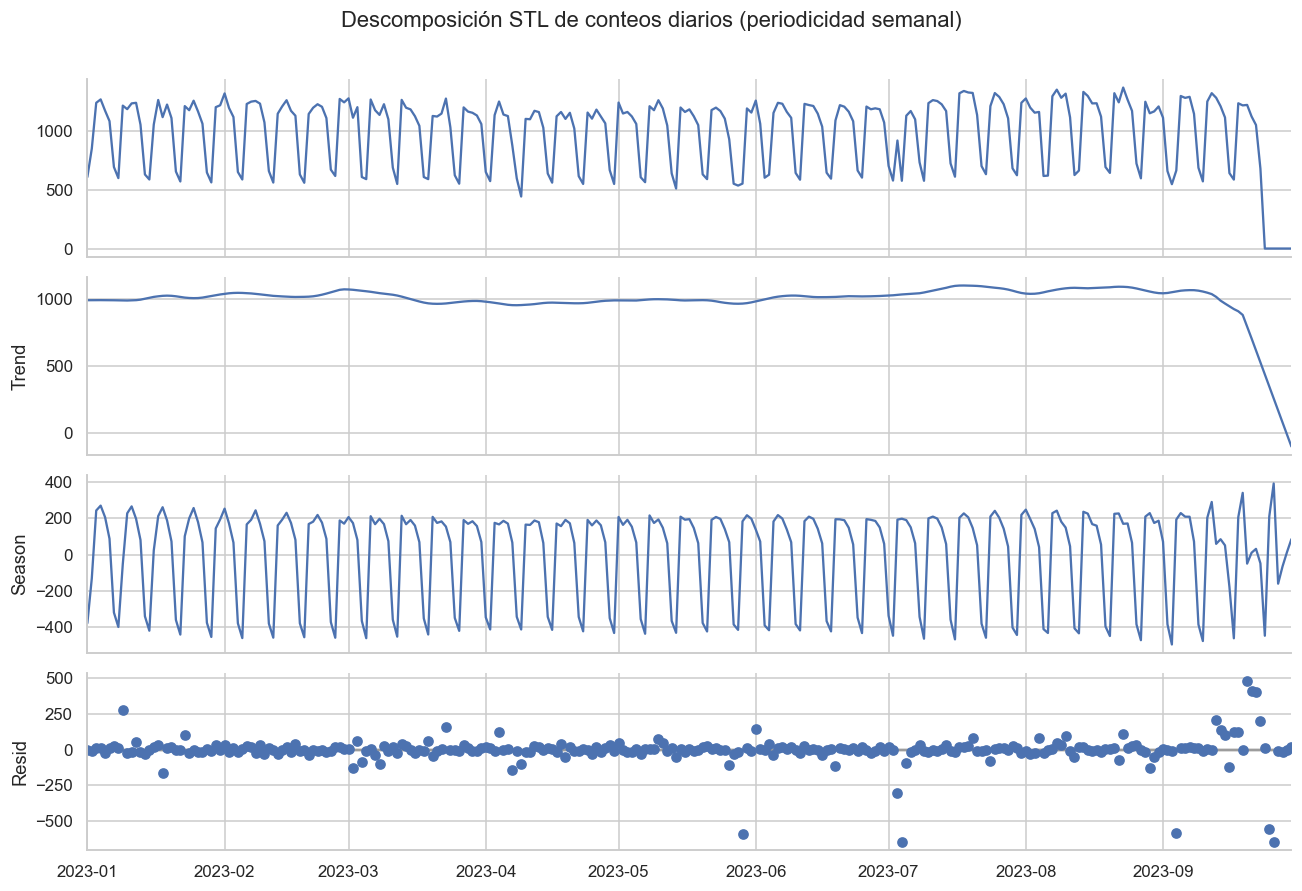

,Prueba,Estadístico,p-valor,Hipótesis nula
0,ADF,-1.583,0.492,raíz unitaria / no estacionaria
1,KPSS,0.237,> 0.10,estacionaria


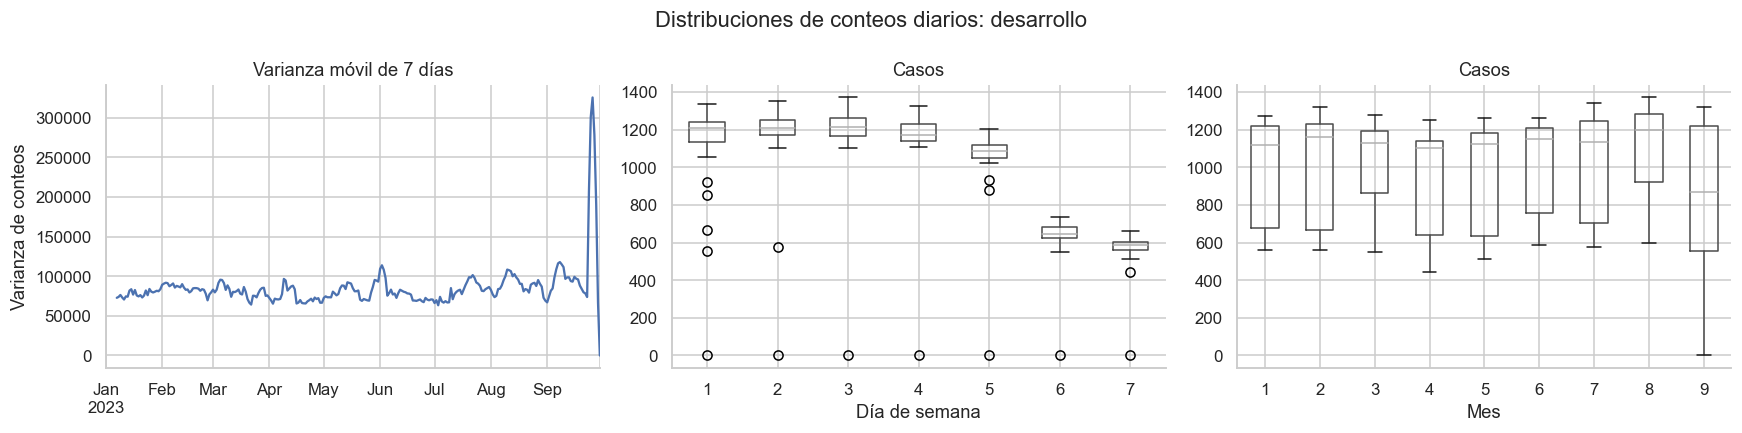

,Rezago (días),Días utilizables,Correlación: proporción manufactura t-k / ausencia t,Correlación tras centrar por día semanal
0,0,266,-0.475,-0.174
1,1,265,-0.270,-0.095
2,7,259,-0.449,-0.036
3,14,252,-0.451,-0.026


Casos diarios                     Desviación respecto al día semanal  \
          Media Desviación estándar                              Media   
1     1,006.387             266.763                             22.126   
2     1,034.429             274.412                             47.190   
3     1,018.613             258.046                             17.079   
4       938.733             264.345                            -22.787   
5       983.419             272.917                            -20.867   
6     1,022.433             252.392                             27.094   
7     1,015.839             290.048                             48.861   
8     1,088.516             272.261                             83.222   
9       774.033             503.428                           -203.787   

                       
  Desviación estándar  
1              69.506  
2              38.352  
3              58.516  
4              47.945  
5             114.202  
6              33.895  
7             140.175  
8              64.587  
9             468.034

El mayor contraste descriptivo entre ventanas consecutivas de 28 días aparece en **2023-09-02**, con diferencia **-309.1 casos/día** tras centrar por día semanal. Es un máximo exploratorio, no una prueba de cambio estructural; no se usa para cambiar el corte.

,Rango entre trimestres de proporción del volumen propio,Rango entre trimestres de proporción de ausencia
Conteo,"1,325.000","1,325.000"
Media,0.182,0.196
Desviación estándar,0.129,0.142
Mínimo,0.000,0.000
25%,0.094,0.091
50%,0.155,0.167
75%,0.229,0.267
90%,0.333,0.385
Máximo,0.892,1.000


Heterogeneidad: **1,325 establecimientos** con ≥30 casos de desarrollo y presencia en los tres trimestres, criterio descriptivo fijado antes del cálculo. No se publican sus identidades. Las correlaciones agregadas no prueban relaciones individuales ni capacidad predictiva. El calendario se describe por semana y mes; no se atribuyen cambios a festivos, políticas o exposición sin datos externos.

ADF p≈0.123 no rechaza raíz unitaria; KPSS p>0.10 no rechaza estacionariedad. Son nulas diferentes: este resultado es inconcluso y no prueba estacionariedad. La cota de KPSS procede de su tabla, no de una probabilidad exacta.

La correlación agregada manufactura–ausencia a siete días pasa de **−0.479** a **−0.049** al centrar por día semanal: gran parte de esa asociación coincide con el calendario, sin probar causalidad. Entre los **3.319 establecimientos** elegibles, la mediana del rango trimestral de proporción de ausencia es **0.165** (16.5 puntos porcentuales). Los volúmenes y composiciones cambian dentro de las entidades; no basta con considerar cada caso independiente. Estos diagnósticos describen el desarrollo y no se convierten en predictores ni cambian el corte.

In [14]:
calendar = pd.date_range('2023-01-01', '2023-09-30', freq='D')
daily_cases = (
    train.groupby(train.incident_date.dt.normalize())
    .size()
    .reindex(calendar, fill_value=0)
)
rolling7 = daily_cases.rolling(7, center=True, min_periods=1).mean()

fig, ax = plt.subplots(figsize=(14, 4))
ax.plot(daily_cases.index, daily_cases.values, alpha=0.35, label='Casos diarios')
ax.plot(rolling7.index, rolling7.values, linewidth=2, label='Media móvil de 7 días')
ax.set(title='Casos reportados por fecha del incidente: entrenamiento',
       xlabel='Fecha', ylabel='Casos')
ax.legend()
plt.tight_layout()
plt.show()

weekday_order = ['Monday','Tuesday','Wednesday','Thursday','Friday','Saturday','Sunday']
weekday_es = {
    'Monday':'Lunes','Tuesday':'Martes','Wednesday':'Miércoles',
    'Thursday':'Jueves','Friday':'Viernes','Saturday':'Sábado','Sunday':'Domingo'
}
weekday = pd.crosstab(train.incident_date.dt.day_name(), train[TARGET]).reindex(weekday_order)
weekday.columns = [OUTCOMES[c] for c in weekday.columns]
weekday.index = [weekday_es[d] for d in weekday.index]
display(weekday.assign(Total=weekday.sum(axis=1)))

fig, axes = plt.subplots(1, 2, figsize=(13, 4))
weekday.sum(axis=1).plot.bar(ax=axes[0])
axes[0].set(title='Casos por día de la semana', xlabel='', ylabel='Casos')
weekday.div(weekday.sum(axis=1), axis=0).mul(100).plot(ax=axes[1], marker='o')
axes[1].set(title='Composición del resultado por día de la semana',
            xlabel='', ylabel='Casos dentro del día (%)')
axes[1].legend(fontsize=7)
plt.tight_layout()
plt.show()

x = daily_cases.to_numpy(dtype=float)
x_centered = x - x.mean()
denom = np.dot(x_centered, x_centered)
max_lag = 30
acf_vals = [1.0]
for lag in range(1, max_lag + 1):
    acf_vals.append(
        np.dot(x_centered[:-lag], x_centered[lag:]) / denom if denom else np.nan
    )

fig, ax = plt.subplots(figsize=(10, 4))
ax.stem(range(max_lag + 1), acf_vals)
ax.set(title='Autocorrelación descriptiva de conteos diarios',
       xlabel='Rezago (días)', ylabel='ACF')
plt.tight_layout()
plt.show()

try:
    from statsmodels.tsa.seasonal import STL
    from statsmodels.tsa.stattools import adfuller, kpss, pacf

    pacf_values=pacf(daily_cases.astype(float),nlags=30,method='ywm')
    fig,ax=plt.subplots(figsize=(10,4))
    ax.stem(range(31),pacf_values)
    ax.set(title='PACF descriptiva de conteos diarios',xlabel='Rezago (días)',ylabel='PACF')
    plt.tight_layout();plt.show()
    stl = STL(daily_cases.astype(float), period=7, robust=True).fit()
    fig = stl.plot()
    fig.set_size_inches(12, 8)
    fig.suptitle('Descomposición STL de conteos diarios (periodicidad semanal)', y=1.01)
    plt.tight_layout()
    plt.show()

    adf_stat, adf_p, *_ = adfuller(daily_cases.astype(float), autolag='AIC')
    import warnings
    with warnings.catch_warnings(record=True) as kpss_warnings:
        warnings.simplefilter('always')
        kpss_stat, kpss_p, *_ = kpss(daily_cases.astype(float), regression='c', nlags='auto')
    kpss_label = '> 0.10' if kpss_p == .1 and kpss_warnings else f'{kpss_p:.3f}'
    display(pd.DataFrame({
        'Prueba': ['ADF', 'KPSS'],
        'Estadístico': [adf_stat, kpss_stat],
        'p-valor': [f'{adf_p:.3f}', kpss_label],
        'Hipótesis nula': ['raíz unitaria / no estacionaria', 'estacionaria']
    }))
except ImportError:
    raise RuntimeError('statsmodels requerido para completar el EDA temporal')
except Exception as exc:
    raise RuntimeError('Fallo en diagnósticos temporales') from exc

from osha_review_checks import temporal_supplement
temporal_supplement(train, display, plt, Markdown)
display(Markdown('ADF p≈0.123 no rechaza raíz unitaria; KPSS p>0.10 no rechaza estacionariedad. Son nulas diferentes: este resultado es inconcluso y no prueba estacionariedad. La cota de KPSS procede de su tabla, no de una probabilidad exacta.'))

display(Markdown('La correlación agregada manufactura–ausencia a siete días pasa de **−0.479** a **−0.049** al centrar por día semanal: gran parte de esa asociación coincide con el calendario, sin probar causalidad. Entre los **3.319 establecimientos** elegibles, la mediana del rango trimestral de proporción de ausencia es **0.165** (16.5 puntos porcentuales). Los volúmenes y composiciones cambian dentro de las entidades; no basta con considerar cada caso independiente. Estos diagnósticos describen el desarrollo y no se convierten en predictores ni cambian el corte.'))


**Componente temporal:** los conteos diarios describen el flujo de reportes de incidentes de múltiples establecimientos, no una serie de riesgo individual. STL/ADF/KPSS, cuando disponibles, son diagnósticos agregados. El modelo se evalúa cronológicamente; las etiquetas no tienen una fecha histórica de disponibilidad verificada.

**Alcance de validación:** desarrollo hasta el 23 de septiembre y prueba octubre–diciembre en establecimientos reservados, sin cruce de grupos. La validación interna avanza en el tiempo, separa grupos y usa una purga fija de siete días, motivada por la dependencia temporal de los reportes y fijada antes de los nuevos ajustes. Los 39 fallecimientos de la prueba permiten calcular métricas, pero la sensibilidad de esa clase seguirá siendo imprecisa. La reserva del cuarto trimestre ya había sido examinada en análisis previos; no se presenta como inédita.

La partición responde a generalización temporal a establecimientos no utilizados para ajustar el modelo. Los casos de esos establecimientos en enero–septiembre y los casos Q4 de establecimientos de desarrollo quedan fuera del ajuste y de la prueba principal. No hay una reconstrucción de disponibilidad histórica de las etiquetas o los predictores.


## 10. Agrupación por establecimiento y medidas descriptivas del lugar de trabajo


,Casos reportados
Conteo,"34,029.000"
Media,7.920
Desviación estándar,26.678
Mínimo,1.000
50%,3.000
90%,15.000
95%,25.000
99%,74.000
Máximo,"2,249.000"


Los 100 establecimientos con más casos concentran 12.19% del entrenamiento.


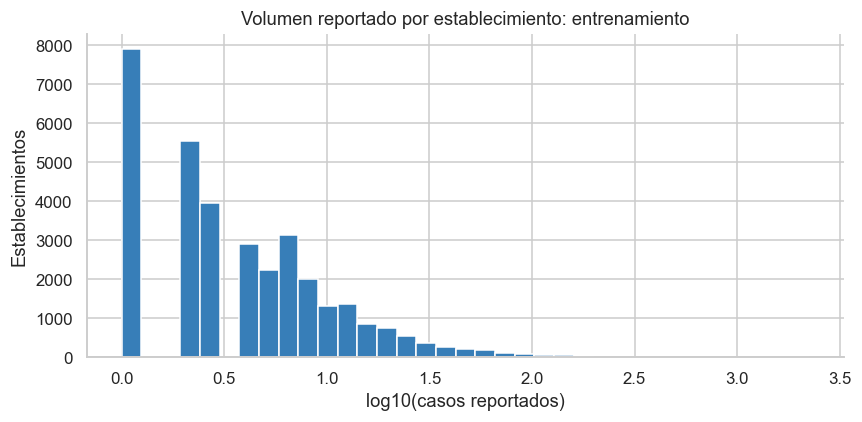

,Conteo,Media,Desviación estándar,Mínimo,50%,90%,99%,Máximo
Casos,"34,029.000",7.920,26.678,1.000,3.000,15.000,74.000,"2,249.000"
Resultados distintos,"34,029.000",1.845,0.788,1.000,2.000,3.000,3.000,4.000
Proporción del resultado más frecuente,"34,029.000",0.766,0.219,0.250,0.750,1.000,1.000,1.000


,Establecimientos con valores inconsistentes
annual_average_employees,0
total_hours_worked,0
size,0


,Conteo,Media,Desviación estándar,Mínimo,25%,50%,75%,Máximo
annual_average_employees,"34,029.000",260.143,"1,996.273",0.000,62.000,125.000,222.000,"218,234.000"
total_hours_worked,"34,029.000","622,645.468","15,383,901.407",0.000,"101,923.000","197,041.000","370,322.000","2,595,152,024.000"


,Conteo
Establecimientos con empleados <= 0,6
Establecimientos con horas <= 0,13


La mediana es **3 casos** por establecimiento; el máximo es **2,249**. Los 100 mayores concentran **12.19 %**. Los casos no son observaciones independientes: se informa solapamiento y se remuestrean establecimientos completos.

In [15]:
cases_per_establishment = train.groupby(GROUP).size().rename('reported_cases')
display(cases_per_establishment.describe(percentiles=[.5,.9,.95,.99]).to_frame())
largest_share = 100*cases_per_establishment.nlargest(100).sum()/len(train)
print(f'Los 100 establecimientos con más casos concentran {largest_share:.2f}% del entrenamiento.')
fig, ax = plt.subplots(figsize=(8,4))
ax.hist(np.log10(cases_per_establishment),bins=35,color='#377eb8')
ax.set(title='Volumen reportado por establecimiento: entrenamiento',xlabel='log10(casos reportados)',ylabel='Establecimientos')
plt.tight_layout(); plt.show()
establishment_outcomes = pd.crosstab(train[GROUP],train[TARGET]).reindex(columns=list(OUTCOMES),fill_value=0)
cluster_summary = pd.DataFrame({'cases':establishment_outcomes.sum(axis=1),
                                'distinct_outcomes':establishment_outcomes.gt(0).sum(axis=1),
                                'largest_outcome_share':establishment_outcomes.max(axis=1)/establishment_outcomes.sum(axis=1)})
display(cluster_summary.describe(percentiles=[.5,.9,.99]).T)
establishment_fields = ['annual_average_employees','total_hours_worked','size']
inconsistent = train.groupby(GROUP)[establishment_fields].nunique(dropna=False).gt(1).sum()
display(inconsistent.rename('establishments_with_inconsistent_values').to_frame())
establishments = train.drop_duplicates(GROUP).set_index(GROUP)
display(eda.numeric_summary(establishments,['annual_average_employees','total_hours_worked']))
display(pd.Series({
    'Establecimientos con empleados <= 0':int(establishments.annual_average_employees.le(0).sum()),
    'Establecimientos con horas <= 0':int(establishments.total_hours_worked.le(0).sum())
},name='count').to_frame())

display(Markdown(f'La mediana es **{cases_per_establishment.median():.0f} casos** por establecimiento; el máximo es **{cases_per_establishment.max():,}**. Los 100 mayores concentran **{largest_share:.2f} %**. Los casos no son observaciones independientes: se informa solapamiento y se remuestrean establecimientos completos.'))


Los totales anuales se resumen una sola vez por establecimiento; no se suman las copias presentes en cada caso. Si existieran inconsistencias internas, el uso del primer registro requeriría revisión. Estas variables siguen excluidas como predictores porque pueden incorporar información posterior al incidente. No hay identificador de trabajador para detectar casos recurrentes de una misma persona. Establecimientos distintos también pueden pertenecer a una misma empresa.



## 11. Auditoría de claves de caso y coherencia del resultado en desarrollo


In [16]:
reused = train.duplicated([GROUP,'case_number'],keep=False)
reused_groups = train.loc[reused].groupby([GROUP,'case_number'],dropna=False)
death_dates = pd.to_datetime(train.date_of_death,format='%m/%d/%Y',errors='coerce')
checks = {
    'Números de caso faltantes':int(train.case_number.isna().sum()),
    'Identificadores ITA duplicados':int(train.id.duplicated().sum()),
    'Filas con clave establecimiento/número de caso repetida':int(reused.sum()),
    'Claves repetidas con varias fechas de incidente':int(reused_groups.incident_date.nunique().gt(1).sum()),
    'Claves repetidas con varios resultados':int(reused_groups[TARGET].nunique().gt(1).sum()),
    'Resultado de ausencia con días de ausencia <= 0':int((train[TARGET].eq(2)&train.dafw_num_away.le(0)).sum()),
    'Resultado de traslado/restricción con días de restricción <= 0':int((train[TARGET].eq(3)&train.djtr_num_tr.le(0)).sum()),
    'Otro caso registrable con días de ausencia/restricción positivos':int((train[TARGET].eq(4)&(train.dafw_num_away.gt(0)|train.djtr_num_tr.gt(0))).sum()),
    'Casos no mortales con fecha de fallecimiento':int((train[TARGET].ne(1)&train.date_of_death.notna()).sum()),
    'Fallecimientos sin fecha de fallecimiento':int((train[TARGET].eq(1)&train.date_of_death.isna()).sum()),
    'Fecha de fallecimiento anterior al incidente':int((death_dates<train.incident_date).sum()),
    'Fechas de fallecimiento presentes no interpretables':int((train.date_of_death.notna()&death_dates.isna()).sum()),
    'Días de ausencia/restricción negativos':int((train.dafw_num_away.lt(0)|train.djtr_num_tr.lt(0)).sum())
}
display(pd.Series(checks,name='cases_or_groups').to_frame())
leakage_audit = pd.crosstab(train.outcome, [train.dafw_num_away.gt(0), train.djtr_num_tr.gt(0)])
leakage_audit.columns.names = ['Días de ausencia positivos','Días de restricción positivos']
display(leakage_audit.reindex(OUTCOMES.values()))

display(Markdown('Las discrepancias entre días y categoría registrada son alertas de calidad. No permiten saber qué campo es erróneo, por lo que se conserva el objetivo y se excluyen días como predictores. Repetir el número de caso no demuestra duplicación, especialmente cuando cambian fecha o desenlace.'))

from osha_review_checks import cross_partition_audit
cross_audit = cross_partition_audit(DATA_PATH, PROJECT_DIR/'osha_temporal_results/cross_partition_audit.json')
audit_labels = {
    'shared_case_keys': 'Claves establecimiento/caso compartidas',
    'shared_ita_ids': 'ID ITA compartidos',
    'development_rows_with_shared_key': 'Filas de desarrollo con clave compartida',
    'test_rows_with_shared_key': 'Filas de prueba con clave compartida',
    'shared_keys_with_matching_content_except_administrative_fields_and_incident_date': 'Claves con contenido coincidente (sin campos excluidos)',
    'matched_content_patterns': 'Patrones de contenido coincidente'}
display(pd.Series({label:cross_audit[key] for key,label in audit_labels.items()}, name='Conteo').to_frame())
display(Markdown('Esta auditoría conserva evidencia de la partición temporal histórica que se examinó antes. La partición nueva no comparte establecimientos por construcción. La auditoría es una comprobación de integridad, no EDA para seleccionar variables. Los ID ITA y los números de caso se comparan por separado; las coincidencias de contenido excluyen ID, número de caso, fecha de envío y fecha del incidente. No se deduplican registros ni se reconstruyen fechas.'))
display(train.establishment_type.fillna('Faltante').value_counts().rename('Casos por código de establecimiento').to_frame())
display(Markdown('El código de establecimiento **0 (377 casos de desarrollo)** no está definido en el diccionario consultado, que documenta 1–3. Se marca semánticamente como **no documentado**, pero se conserva como categoría literal 0 en el modelo ya fijado. No se presupone que signifique privado ni se fusiona silenciosamente con faltantes.'))

display(Markdown('En la partición temporal histórica, la revisión campo a campo confirmó **dos patrones de contenido coincidente en una clave**, que abarcan **cinco registros (tres de desarrollo y dos de prueba históricos)**, con fechas distintas y separaciones de 86 y 226 días dentro de cada patrón. Coinciden seis campos narrativos presentes, que no se publican. Esto mantiene una posible contaminación residual por duplicados, pero no permite decidir si son incidentes idénticos. Se conservan los registros; evidencia en `content_flag_detail.json` y `audit_content_flags.py`.'))


,Casos o grupos
Números de caso faltantes,6
Identificadores ITA duplicados,0
Filas con clave establecimiento/número de caso repetida,25173
Claves repetidas con varias fechas de incidente,3228
Claves repetidas con varios resultados,2299
Resultado de ausencia con días de ausencia <= 0,623
Resultado de traslado/restricción con días de restricción <= 0,366
Otro caso registrable con días de ausencia/restricción positivos,424
Casos no mortales con fecha de fallecimiento,0
Fallecimientos sin fecha de fallecimiento,0


Días de ausencia positivos     False         True        
Días de restricción positivos  False  True   False  True 
Resultado                                                
Fallecimiento (Death)             59      0     10      0
Días de ausencia                 337    286  70119  28955
Traslado / restricción           312  79226     54    256
Otro caso registrable          89478    249    128     47

Las discrepancias entre días y categoría registrada son alertas de calidad. No permiten saber qué campo es erróneo, por lo que se conserva el objetivo y se excluyen días como predictores. Repetir el número de caso no demuestra duplicación, especialmente cuando cambian fecha o desenlace.

,Conteo
Claves establecimiento/caso compartidas,2107
ID ITA compartidos,0
Filas de desarrollo con clave compartida,26654
Filas de prueba con clave compartida,10603
Claves con contenido coincidente (sin campos excluidos),1
Patrones de contenido coincidente,2


Esta auditoría conserva evidencia de la partición temporal histórica que se examinó antes. La partición nueva no comparte establecimientos por construcción. La auditoría es una comprobación de integridad, no EDA para seleccionar variables. Los ID ITA y los números de caso se comparan por separado; las coincidencias de contenido excluyen ID, número de caso, fecha de envío y fecha del incidente. No se deduplican registros ni se reconstruyen fechas.

,Casos por código de establecimiento
1,252547
2,8743
3,7676
Faltante,307
0,243


El código de establecimiento **0 (377 casos de desarrollo)** no está definido en el diccionario consultado, que documenta 1–3. Se marca semánticamente como **no documentado**, pero se conserva como categoría literal 0 en el modelo ya fijado. No se presupone que signifique privado ni se fusiona silenciosamente con faltantes.

En la partición temporal histórica, la revisión campo a campo confirmó **dos patrones de contenido coincidente en una clave**, que abarcan **cinco registros (tres de desarrollo y dos de prueba históricos)**, con fechas distintas y separaciones de 86 y 226 días dentro de cada patrón. Coinciden seis campos narrativos presentes, que no se publican. Esto mantiene una posible contaminación residual por duplicados, pero no permite decidir si son incidentes idénticos. Se conservan los registros; evidencia en `content_flag_detail.json` y `audit_content_flags.py`.

El número de caso del empleador no constituye una clave fiable para deduplicar: puede repetirse en fechas y resultados distintos. Las coincidencias tras eliminar identificadores administrativos son sospechosas, pero también pueden surgir por anonimización o descripciones generales idénticas. No se deduplican ni se cambian etiquetas silenciosamente. Las discrepancias entre resultado y días son alertas de calidad, no autorización para reconstruir el objetivo usando información filtrada. La partición temporal no impide coincidencias de contenido entre periodos. No se dispone de una clave fiable de caso más allá del ID ITA; esta incertidumbre se declara y las claves repetidas no se eliminan automáticamente.



## 12. Referencia preliminar de viabilidad: resultados conservados

La evaluación preliminar utilizó imputación constante y codificación one-hot aprendidas solo en entrenamiento, seguidas de `LogisticRegression(class_weight='balanced', max_iter=1000, random_state=42)`. Se conserva su advertencia y sus resultados como registro histórico; **no son el ajuste numéricamente corregido** presentado después. No se vuelve a ejecutar este modelo histórico.


In [17]:
display(pd.DataFrame({
    'logistic_regression':[baseline['balanced_accuracy'],baseline['accuracy'],baseline['macro_f1']],
    'constant_reference':[baseline['constant_classifier_balanced_accuracy_reference'],baseline['majority_accuracy_reference'],np.nan]
},index=['Exactitud balanceada','Exactitud','F1 macro']))
display(pd.DataFrame(baseline['confusion_matrix'],index=[f'Observado: {OUTCOMES[c]}' for c in baseline['confusion_matrix_labels']],
                     columns=[f'Predicho: {OUTCOMES[c]}' for c in baseline['confusion_matrix_labels']]))
print('Iteraciones registradas:',baseline['iterations'])
print('Advertencias históricas:')
for warning in baseline['warnings']:
    print('ConvergenceWarning: lbfgs alcanzó el límite de 1.000 iteraciones sin converger. Se conserva la advertencia del cribado; el ajuste corregido se presenta más adelante.')
display(pd.DataFrame({OUTCOMES[int(c)]:v for c,v in baseline['classification_report'].items() if c in ['1','2','3','4']}).T)


,LogisticRegression histórico,Referencia constante
Exactitud balanceada,0.419,0.250
Exactitud,0.480,0.366
F1 macro,0.374,NaN


,Predicho: Fallecimiento (Death),Predicho: Días de ausencia,Predicho: Traslado / restricción,Predicho: Otro caso registrable
Observado: Fallecimiento (Death),15,15,15,23
Observado: Días de ausencia,6008,23717,18743,17041
Observado: Traslado / restricción,4760,8155,28231,11899
Observado: Otro caso registrable,4197,8774,13483,33875


Iteraciones registradas: [1000]
Advertencias históricas:


,Precisión,Sensibilidad,F1,Casos
Fallecimiento (Death),0.001,0.221,0.002,68.000
Días de ausencia,0.583,0.362,0.447,"65,509.000"
Traslado / restricción,0.467,0.532,0.497,"53,045.000"
Otro caso registrable,0.539,0.562,0.550,"60,329.000"


## 13. Síntesis del EDA y continuidad

| Hallazgo | Implicación | Decisión aplicada |
|---|---|---|
| Death es extremadamente infrecuente | Exactitud global oculta errores de la clase rara | Conservar cuatro clases; informar métricas por clase, soporte e incertidumbre; no cambiar umbrales |
| Días de ausencia/restricción y fecha de muerte revelan desenlace | Fuga directa si se usan como predictores | Excluirlos del modelo; usarlos solo para auditoría |
| SOC fue codificado retrospectivamente | No hay prueba de disponibilidad al ocurrir el incidente | Formular clasificación retrospectiva; no alerta temprana |
| NAICS, SOC y horas presentan faltantes/códigos especiales | Cero y faltante no son universalmente equivalentes | Mantener reglas documentadas e imputación constante dentro del pipeline |
| Códigos nominales y horas requieren decisiones distintas según propósito | Distancias sobre identificadores no son magnitudes | One-hot en modelo; SVD exploratorio con horas estandarizadas claramente separado |
| Casos concentrados y repetidos dentro de establecimientos | Filas dependientes y posible optimismo al reutilizar entidades | Separar empresas en desarrollo, validación y prueba; bootstrap por establecimiento |
| Patrón semanal, cambios de composición y dependencia de errores | Estabilidad temporal y precisión de intervalos no garantizadas | Validación hacia adelante con purga de siete días; EDA temporal solo de desarrollo |
| Números de caso repetidos no identifican inequívocamente duplicados | Deduplicar por clave puede eliminar incidentes reales | Auditoría de ID, clave y contenido; conservar datos y documentar incertidumbre |
| Asociación categórica no demuestra causalidad ni fuga por sí sola | Significancia clásica no resuelve dependencia | Priorizar tamaños de asociación y disponibilidad; no seleccionar predictores por p-valores |
| Archivo de casos reportados con cobertura selectiva y sin población expuesta | No estima riesgo de lesión ni describe a todos los trabajadores | Limitar conclusiones a resultados entre casos publicados; no clasificar empleadores como peligrosos |

La [matriz de requisitos](compliance_matrix.md) distingue evidencia, decisiones y límites. Se conserva el objetivo de cuatro clases y no se optimiza el modelo para mejorar resultados.


In [18]:
assert (DATA_PATH.stat().st_size,DATA_PATH.stat().st_mtime_ns) == raw_signature
assert hashlib.sha256(UTILS_PATH.read_bytes()).hexdigest() == utils_hash
assert set(feature_view.columns) == set(baseline['features'])
assert not set(feature_view.columns)&{'id',GROUP,'case_number','dafw_num_away','djtr_num_tr','date_of_death'}
assert len(train)==269516 and train.incident_date.max()<pd.Timestamp('2023-09-24')
assert not set(train[GROUP]).intersection(test_group_ids)
assert train[TARGET].value_counts().sort_index().to_dict()=={1:69,2:99697,3:79848,4:89902}
assert len(plt.get_fignums())==0
print('Verificado: datos originales intactos; EDA restringido a enero–septiembre.')


Verificado: datos originales intactos; EDA restringido a enero–septiembre.


## 14. Modelo base y protocolo fijado

LogisticRegression con parámetros documentados y DummyClassifier. Tres ventanas hacia adelante: entrenar antes de abril y validar abril–mayo; entrenar antes de junio y validar junio–julio; entrenar antes de agosto y validar agosto–septiembre. En cada pliegue, los establecimientos de validación están ausentes del entrenamiento y se purgan los siete días previos. Fracciones de aprendizaje anidadas (25 %, 50 %, 100 %) usan establecimientos completos. No hay búsqueda de hiperparámetros ni selección por resultados de prueba.


In [19]:
pd.set_option('display.float_format', lambda x: f'{x:,.6f}')
import joblib
sys.path.insert(0, str(PROJECT_DIR.resolve()))
from sklearn.metrics import roc_curve, precision_recall_curve, average_precision_score, roc_auc_score
from sklearn.calibration import calibration_curve
from osha_deliverable_utils import make_pipeline, make_dummy, prepare_features, PARAMS, SEED, FEATURES
from osha_group_time_study import run_study

CACHE_DIR = PROJECT_DIR/'osha_group_time_results'
print('Especificación de LogisticRegression:', PARAMS)
print('Pipeline: preparación determinista → imputación constante → one-hot → LogisticRegression')
print('DummyClassifier: strategy=prior; no usa predictores.')
evaluation = run_study(DATA_PATH, CACHE_DIR)
assert evaluation['train_rows'] == len(train) and evaluation['test_rows'] == holdout_rows
assert evaluation['train_groups'] == train[GROUP].nunique() and evaluation['test_groups'] == holdout_groups
assert evaluation['group_overlap'] == 0 and evaluation['final_fit']['converged']
assert evaluation['train_case_hash'] == __import__('osha_deliverable_utils').digest(train.id)
print('Convergencia del ajuste final:', 'Sí' if evaluation['final_fit']['converged'] else 'No')
print('Iteraciones del ajuste final:', evaluation['final_fit']['iterations'])
print('Advertencias del ajuste final:', evaluation['final_fit']['warnings'] or 'Ninguna')
print('Casos/establecimientos de desarrollo:', evaluation['train_rows'], evaluation['train_groups'])
print('Casos/establecimientos de prueba:', evaluation['test_rows'], evaluation['test_groups'])
print('Columnas tras one-hot:', evaluation['encoded_features'])
print('Relación n/p antes de one-hot:', evaluation['train_rows']/len(FEATURES))
print('Relación n/p después de one-hot:', evaluation['train_rows']/evaluation['encoded_features'])


Especificación de LogisticRegression: {'solver': 'newton-cg', 'max_iter': 1000, 'class_weight': 'balanced', 'random_state': 42}
Pipeline: preparación determinista → imputación constante → one-hot → LogisticRegression
DummyClassifier: strategy=prior; no usa predictores.


Ajustando: cv1_fraction25 | casos: 15015


Completado: cv1_fraction25 | convergió: True | iteraciones: [21]


Ajustando: cv1_fraction50 | casos: 28593


Completado: cv1_fraction50 | convergió: True | iteraciones: [21]


...

Bootstrap por establecimiento: 600 / 1000


Bootstrap por establecimiento: 800 / 1000


Bootstrap por establecimiento: 1000 / 1000


Group-time study completed.


Convergencia del ajuste final: Sí
Iteraciones del ajuste final: [27]
Advertencias del ajuste final: Ninguna
Casos/establecimientos de desarrollo: 269516 34029
Casos/establecimientos de prueba: 127391 34182
Columnas tras one-hot: 1433
Relación n/p antes de one-hot: 33689.5
Relación n/p después de one-hot: 188.0781577110956


## 15. Validación cronológica y agrupada

Cada pliegue predice un periodo posterior con establecimientos que no aparecen en el entrenamiento. Se purgan siete días entre entrenamiento y validación. Los soportes de Death son pequeños en los pliegues, por lo que sus métricas se leen como exploratorias y con incertidumbre; las tres clases frecuentes tienen soporte amplio. Las desviaciones entre pliegues no son intervalos de confianza ni experimentos independientes.


In [20]:
METRIC_LABELS = {'accuracy':'Exactitud','precision_weighted':'Precisión ponderada','recall_weighted':'Sensibilidad ponderada',
                 'f1_weighted':'F1 ponderado','macro_f1':'F1 macro','balanced_accuracy':'Exactitud balanceada',
                 'roc_auc_macro_ovr':'ROC AUC macro (uno contra el resto)',
                 'average_precision_macro_ovr':'Precisión promedio macro (uno contra el resto)',
                 'brier_multiclass':'Brier multiclase (menor es mejor)','log_loss':'Pérdida logarítmica (menor es mejor)'}
cv_rows=[]
for row in evaluation['cv']:
    cv_rows.append({'Modelo':row['model'],'Pliegue':row['fold'],'Casos de entrenamiento':row['train_rows'],
                    'Casos de validación':row['validation_rows'],'Establecimientos de entrenamiento':row['train_groups'],
                    'Establecimientos de validación':row['validation_groups'],'Establecimientos compartidos':row['group_overlap'],
                    'Fallecimientos en validación':row['validation_deaths'],
                    **{METRIC_LABELS[k]:v for k,v in row['metrics'].items()}})
cv_table=pd.DataFrame(cv_rows)
display(cv_table)
primary_columns=[METRIC_LABELS[k] for k in ['balanced_accuracy','macro_f1','roc_auc_macro_ovr','accuracy']]
cv_summary=cv_table.groupby('Modelo')[primary_columns].agg(['mean','std'])
cv_summary.columns=pd.MultiIndex.from_tuples([(a,{'mean':'Media','std':'Desviación estándar'}[b]) for a,b in cv_summary.columns])
display(cv_summary)
assert all(pd.Timestamp(r['train_date_max']) < pd.Timestamp(r['validation_date_min']) - pd.Timedelta(days=7) and r['group_overlap']==0 for r in evaluation['cv'])
print('Convergencia de los ajustes de validación y aprendizaje:', 'Sí' if all(row['converged'] for row in evaluation['learning_curve']) else 'No')
display(pd.DataFrame([{'Pliegue':r['fold'],'Fracción':r['fraction'],'Iteraciones':r['iterations'][0],
                       'Convergió':r['converged'],'Fallecimientos de entrenamiento':r['train_deaths']}
                      for r in evaluation['learning_curve']]))


,Modelo,Pliegue,Casos de entrenamiento,Casos de validación,Establecimientos de entrenamiento,Establecimientos de validación,...,F1 macro,Exactitud balanceada,ROC AUC macro (uno contra el resto),Precisión promedio macro (uno contra el resto),Brier multiclase (menor es mejor),Pérdida logarítmica (menor es mejor)
0,LogisticRegression,1,56063,20232,15038,6488,...,0.374572,0.380036,0.762247,0.406451,0.601738,1.014692
1,DummyClassifier,1,56063,20232,15038,6488,...,0.125984,0.250000,0.500000,0.250000,0.672590,1.107505
2,LogisticRegression,2,95908,20866,18687,6618,...,0.379290,0.382841,0.629217,0.412616,0.595508,1.004245
3,DummyClassifier,2,95908,20866,18687,6618,...,0.130468,0.250000,0.500000,0.250000,0.666548,1.099563
4,LogisticRegression,3,138669,20551,21048,6700,...,0.390995,0.392242,0.686908,0.432954,0.582758,0.993814
5,DummyClassifier,3,138669,20551,21048,6700,...,0.131557,0.250000,0.500000,0.250000,0.665737,1.099811


Exactitud balanceada                     F1 macro  \
                                  Media Desviación estándar    Media   
Modelo                                                                 
DummyClassifier                0.250000            0.000000 0.129337   
LogisticRegression             0.385040            0.006393 0.381619   

                                       ROC AUC macro (uno contra el resto)  \
                   Desviación estándar                               Media   
Modelo                                                                       
DummyClassifier               0.002954                            0.500000   
LogisticRegression            0.008456                            0.692791   

                                       Exactitud                      
                   Desviación estándar     Media Desviación estándar  
Modelo                                                                
DummyClassifier               0.000000  0.348989            0.010708  
LogisticRegression            0.066710  0.510204            0.007559

Convergencia de los ajustes de validación y aprendizaje: Sí


,Pliegue,Fracción,Iteraciones,Convergió,Fallecimientos de entrenamiento
0,1,0.250000,21,True,5
1,1,0.500000,21,True,8
2,1,1.000000,22,True,16
3,2,0.250000,21,True,9
4,2,0.500000,22,True,16
5,2,1.000000,23,True,27
6,3,0.250000,21,True,10
7,3,0.500000,23,True,13
8,3,1.000000,25,True,37


## 16. Curva de aprendizaje

Fracciones de 25 %, 50 % y 100 % de establecimientos completos de cada entrenamiento cronológico, con validación fija y disjunta por empresa. Las fracciones son anidadas, seleccionadas con semilla y sin resultados de prueba. El eje informa los casos realmente incluidos.


,Fracción,Pliegue,Casos,Establecimientos,Exactitud balanceada: entrenamiento,Exactitud balanceada: validación,F1 macro: entrenamiento,F1 macro: validación
0,0.250000,1,15015,3760,0.703510,0.368130,0.503924,0.364393
1,0.500000,1,28593,7519,0.689068,0.374292,0.456722,0.369407
2,1.000000,1,56063,15038,0.671818,0.380036,0.434124,0.374572
3,0.250000,2,23672,4672,0.684939,0.374759,0.468560,0.370280
4,0.500000,2,48667,9344,0.670049,0.380235,0.443551,0.376677
5,1.000000,2,95908,18687,0.661641,0.382841,0.424399,0.379290
6,0.250000,3,35357,5262,0.673402,0.386629,0.492366,0.383918
7,0.500000,3,70405,10524,0.665606,0.392191,0.436064,0.389318
8,1.000000,3,138669,21048,0.654784,0.392242,0.412425,0.390995


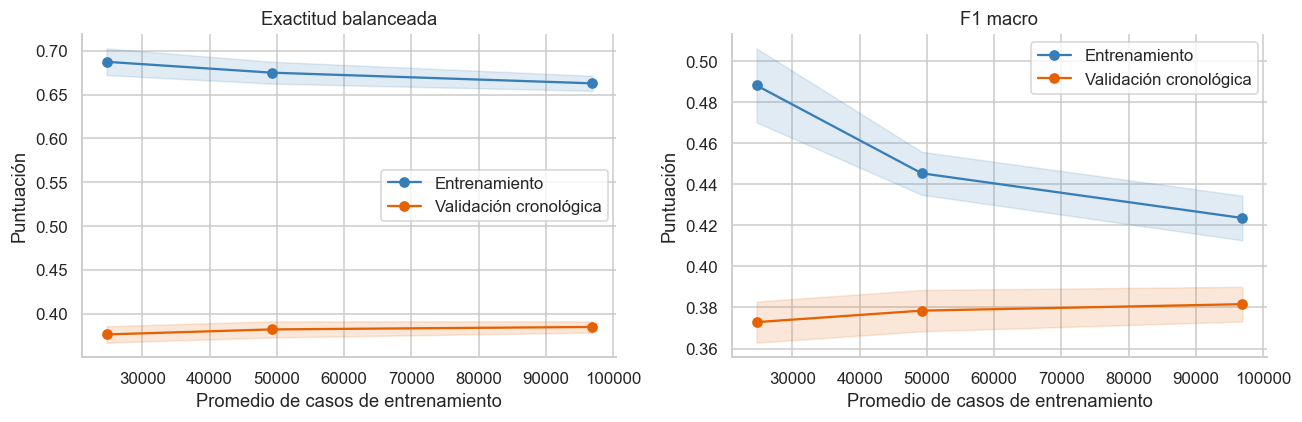

Entre 50 % y 100 % de establecimientos, la exactitud balanceada media de validación cambia **+0.0028**. Con todos los establecimientos disponibles, la brecha media entrenamiento–validación es **0.2777**. La curva permite valorar la tendencia dentro del rango observado; no demuestra que añadir filas de los mismos establecimientos tenga el mismo beneficio que incorporar establecimientos nuevos. Tampoco garantiza mejoras fuera de este periodo ni resuelve la escasez de fallecimientos.

In [21]:
learning_rows=[]
for r in evaluation['learning_curve']:
    learning_rows.append({'fraction':r['fraction'],'fold':r['fold'],'rows':r['train_rows'],'groups':r['train_groups'],
                         'train_balanced_accuracy':r['train_metrics']['balanced_accuracy'],
                         'validation_balanced_accuracy':r['validation_metrics']['balanced_accuracy'],
                         'train_macro_f1':r['train_metrics']['macro_f1'],
                         'validation_macro_f1':r['validation_metrics']['macro_f1']})
learning_table=pd.DataFrame(learning_rows)
display(learning_table.rename(columns={'fraction':'Fracción','fold':'Pliegue','rows':'Casos','groups':'Establecimientos',
    'train_balanced_accuracy':'Exactitud balanceada: entrenamiento','validation_balanced_accuracy':'Exactitud balanceada: validación',
    'train_macro_f1':'F1 macro: entrenamiento','validation_macro_f1':'F1 macro: validación'}))
learning_summary=learning_table.groupby('fraction').agg(['mean','std'])
fig,axes=plt.subplots(1,2,figsize=(12,4))
for ax,metric,title in zip(axes,['balanced_accuracy','macro_f1'],['Exactitud balanceada','F1 macro']):
    x=learning_summary[('rows','mean')].to_numpy()
    for part,label,color in [('train','Entrenamiento','#377eb8'),('validation','Validación cronológica','#e66101')]:
        mean=learning_summary[(part+'_'+metric,'mean')].to_numpy()
        std=learning_summary[(part+'_'+metric,'std')].to_numpy()
        ax.plot(x,mean,'o-',label=label,color=color)
        ax.fill_between(x,mean-std,mean+std,alpha=.15,color=color)
    ax.set(title=title,xlabel='Promedio de casos de entrenamiento',ylabel='Puntuación')
    ax.legend()
plt.tight_layout();plt.show()
curve_delta=float(learning_summary.loc[1.0,('validation_balanced_accuracy','mean')]-learning_summary.loc[.5,('validation_balanced_accuracy','mean')])
curve_gap=float(learning_summary.loc[1.0,('train_balanced_accuracy','mean')]-learning_summary.loc[1.0,('validation_balanced_accuracy','mean')])
display(Markdown(f'Entre 50 % y 100 % de establecimientos, la exactitud balanceada media de validación cambia **{curve_delta:+.4f}**. '
                 f'Con todos los establecimientos disponibles, la brecha media entrenamiento–validación es **{curve_gap:.4f}**. '
                 'La curva permite valorar la tendencia dentro del rango observado; no demuestra que añadir filas de los mismos establecimientos tenga el mismo beneficio que incorporar establecimientos nuevos. '
                 'Tampoco garantiza mejoras fuera de este periodo ni resuelve la escasez de fallecimientos.'))


La interpretación cuantitativa de la curva se genera a partir de los ajustes cronológicos anteriores. La brecha entrenamiento–validación y la tendencia se valoran sin modificar el modelo.

,LogisticRegression,DummyClassifier
Exactitud,0.523797,0.362420
Precisión ponderada,0.545451,0.131348
Sensibilidad ponderada,0.523797,0.362420
F1 ponderado,0.528647,0.192816
F1 macro,0.396591,0.133006
Exactitud balanceada,0.401928,0.250000
ROC AUC macro (uno contra el resto),0.693339,0.500000
Precisión promedio macro (uno contra el resto),0.436582,0.250000
Brier multiclase (menor es mejor),0.583329,0.664404
Pérdida logarítmica (menor es mejor),1.000859,1.097284


,Modelo,Resultado,Precisión,Sensibilidad,F1,Casos
0,LogisticRegression,Fallecimiento (Death),0.000333,0.025641,0.000657,39
1,LogisticRegression,Días de ausencia,0.600472,0.435725,0.505002,46169
2,LogisticRegression,Traslado / restricción,0.477608,0.561709,0.516256,37231
3,LogisticRegression,Otro caso registrable,0.545609,0.584638,0.564450,43952
4,DummyClassifier,Fallecimiento (Death),0.000000,0.000000,0.000000,39
5,DummyClassifier,Días de ausencia,0.362420,1.000000,0.532024,46169
6,DummyClassifier,Traslado / restricción,0.000000,0.000000,0.000000,37231
7,DummyClassifier,Otro caso registrable,0.000000,0.000000,0.000000,43952


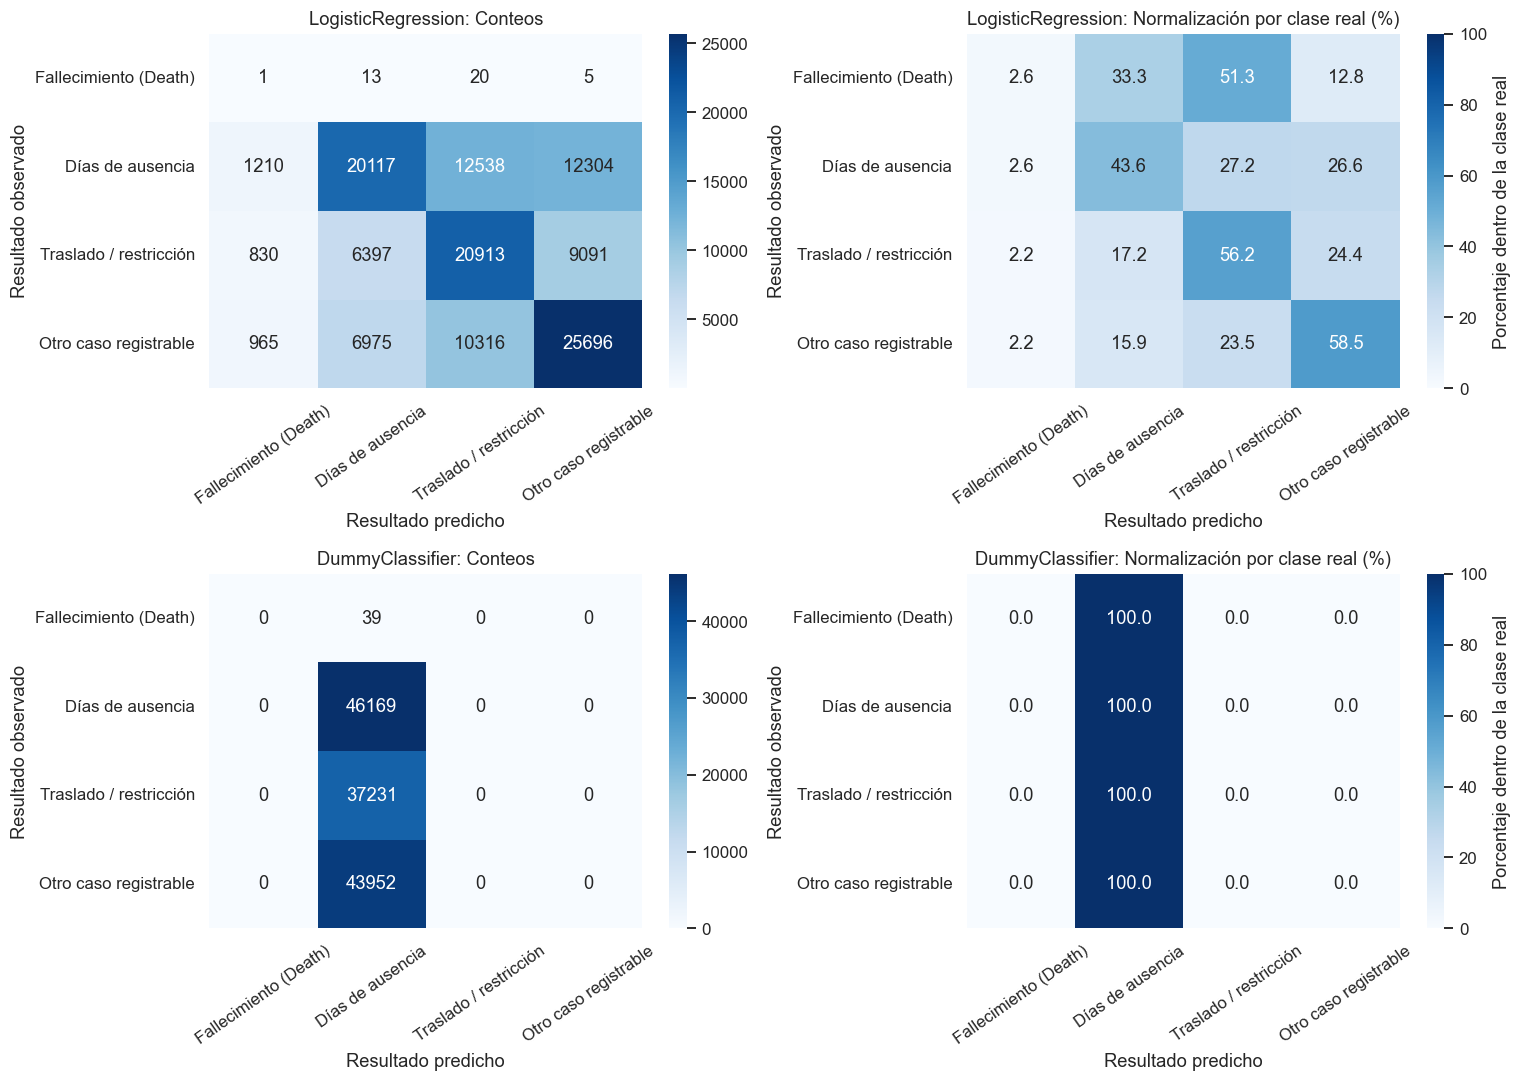

En la reserva hay **39 casos Death**, distribuidos en **39 establecimientos**. LogisticRegression obtiene precisión **0.033 %**, sensibilidad **2.56 %** y F1 **0.0007** para esta clase. El intervalo Wilson del 95 % para sensibilidad es [0.004540703100990098, 0.13180990169850076]. La métrica es imprecisa con este soporte; no demuestra una capacidad fiable para detectar fallecimientos. No se elimina Death ni se agrupa con otra clase para mejorar las métricas.

In [22]:
predictions=np.load(CACHE_DIR/'holdout_predictions.npz',allow_pickle=False)
y_test=predictions['y']
probabilities={'LogisticRegression':predictions['lr'],'DummyClassifier':predictions['dummy']}
assert len(y_test)==holdout_rows and set(y_test)=={1,2,3,4}
scores=pd.DataFrame(evaluation['holdout_metrics']).rename(index=METRIC_LABELS)
display(scores)
reports=[]
for model,report in evaluation['classification_reports'].items():
    for label in [1,2,3,4]:
        r=report[str(label)]
        reports.append({'Modelo':model,'Resultado':OUTCOMES[label],'Precisión':r['precision'],
                        'Sensibilidad':r['recall'],'F1':r['f1-score'],'Casos':int(r['support'])})
display(pd.DataFrame(reports))
fig,axes=plt.subplots(2,2,figsize=(14,10))
for row,model in enumerate(probabilities):
    cm=np.array(evaluation['confusion_matrices'][model])
    labels=list(OUTCOMES.values())
    sns.heatmap(cm,annot=True,fmt='d',cmap='Blues',xticklabels=labels,yticklabels=labels,ax=axes[row,0])
    sns.heatmap(cm/cm.sum(axis=1,keepdims=True)*100,annot=True,fmt='.1f',vmin=0,vmax=100,cmap='Blues',
                xticklabels=labels,yticklabels=labels,ax=axes[row,1],cbar_kws={'label':'Porcentaje dentro de la clase real'})
    for col,title in enumerate(['Conteos','Normalización por clase real (%)']):
        axes[row,col].set(title=model+': '+title,xlabel='Resultado predicho',ylabel='Resultado observado')
        axes[row,col].tick_params(axis='x',rotation=35)
plt.tight_layout();plt.show()
death=evaluation['classification_reports']['LogisticRegression']['1']
display(Markdown(f'En la reserva hay **{int(death["support"])} casos Death**, distribuidos en '
                 f'**{evaluation["test_death_groups"]} establecimientos**. LogisticRegression obtiene precisión '
                 f'**{100*death["precision"]:.3f} %**, sensibilidad **{100*death["recall"]:.2f} %** y F1 **{death["f1-score"]:.4f}** para esta clase. '
                 f'El intervalo Wilson del 95 % para sensibilidad es {evaluation["death_sensitivity_wilson_ci95"]}. La métrica es imprecisa con este soporte; no demuestra una capacidad fiable para detectar fallecimientos. No se elimina Death ni se agrupa con otra clase para mejorar las métricas.'))


## 18. Curvas ROC y precisión–sensibilidad multiclase

Cada panel considera una clase positiva frente a las otras tres. Las curvas ROC pueden parecer favorables cuando hay muchos negativos; para Death debe prestarse especial atención a precisión–sensibilidad y AP. La referencia de AP sin información es la prevalencia de cada clase. AP es precisión promedio escalonada y no el área trapezoidal de la curva PR.

El panel PR de Death usa escala logarítmica en precisión para hacer visible su prevalencia muy baja; los puntos de precisión cero no son representables en esa escala. Los demás paneles conservan escala lineal.


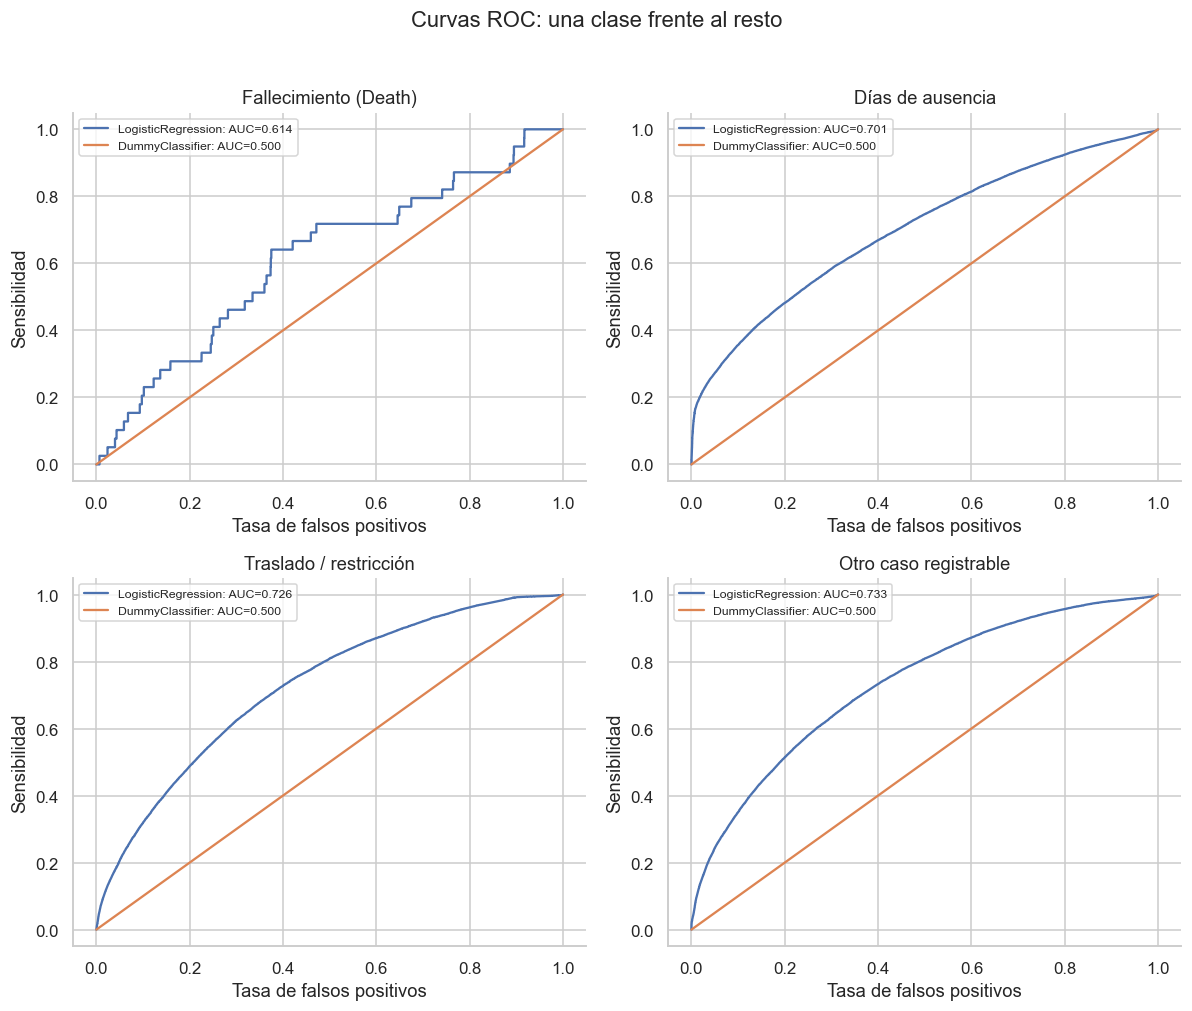

,Modelo,Resultado,ROC AUC OvR,AP OvR,Prevalencia
0,LogisticRegression,Fallecimiento (Death),0.613588,0.000504,0.000306
1,DummyClassifier,Fallecimiento (Death),0.500000,0.000306,0.000306
2,LogisticRegression,Días de ausencia,0.700761,0.625345,0.362420
3,DummyClassifier,Días de ausencia,0.500000,0.362420,0.362420
4,LogisticRegression,Traslado / restricción,0.725560,0.518257,0.292258
5,DummyClassifier,Traslado / restricción,0.500000,0.292258,0.292258
6,LogisticRegression,Otro caso registrable,0.733447,0.602221,0.345017
7,DummyClassifier,Otro caso registrable,0.500000,0.345017,0.345017


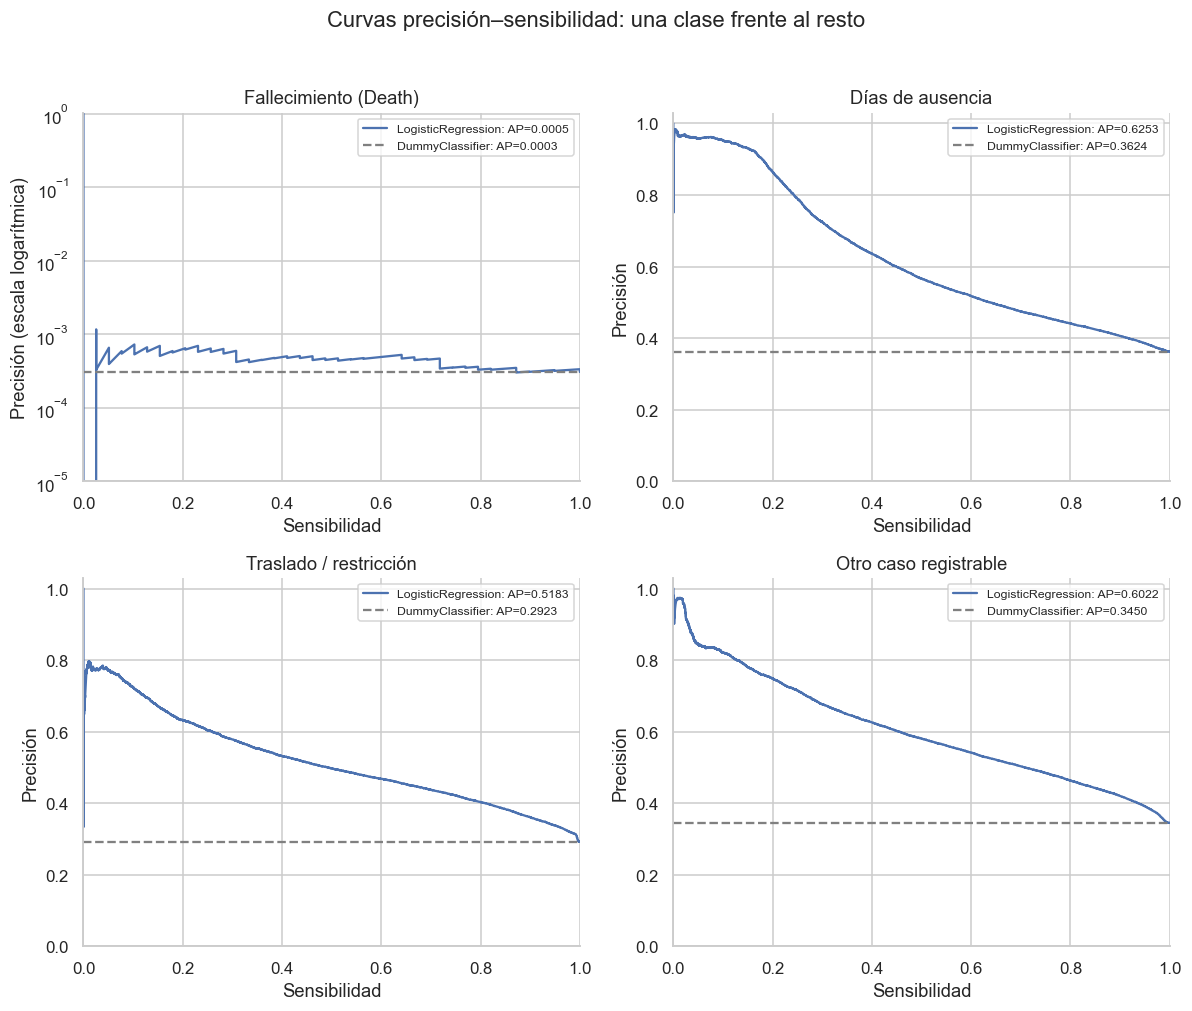

In [23]:
fig,axes=plt.subplots(2,2,figsize=(11,9))
ap_rows=[]
for k,ax in enumerate(axes.flat):
    label=k+1; binary=(y_test==label)
    for model,p in probabilities.items():
        fpr,tpr,_=roc_curve(binary,p[:,k])
        auc=roc_auc_score(binary,p[:,k])
        ax.plot(fpr,tpr,label=f'{model}: AUC={auc:.3f}')
        ap_rows.append({'Modelo':model,'Resultado':OUTCOMES[label],
                        'ROC AUC OvR':auc,'AP OvR':average_precision_score(binary,p[:,k]),
                        'Prevalencia':binary.mean()})
    ax.set(title=OUTCOMES[label],xlabel='Tasa de falsos positivos',ylabel='Sensibilidad')
    ax.legend(fontsize=8)
fig.suptitle('Curvas ROC: una clase frente al resto',y=1.02)
plt.tight_layout();plt.show()
display(pd.DataFrame(ap_rows))
fig,axes=plt.subplots(2,2,figsize=(11,9))
for k,ax in enumerate(axes.flat):
    binary=(y_test==k+1)
    precision,recall,_=precision_recall_curve(binary,probabilities['LogisticRegression'][:,k])
    ap=average_precision_score(binary,probabilities['LogisticRegression'][:,k])
    ax.plot(recall,precision,label=f'LogisticRegression: AP={ap:.4f}')
    ax.axhline(binary.mean(),linestyle='--',color='gray',label=f'DummyClassifier: AP={binary.mean():.4f}')
    ax.set(title=OUTCOMES[k+1],xlabel='Sensibilidad',ylabel='Precisión',xlim=(0,1),ylim=(0,1.03))
    if k==0:
        ax.set_yscale('log')
        ax.set_ylim(1e-5,1.03)
        ax.set_ylabel('Precisión (escala logarítmica)')
    ax.legend(fontsize=8)
fig.suptitle('Curvas precisión–sensibilidad: una clase frente al resto',y=1.02)
plt.tight_layout();plt.show()


## 19. Incertidumbre condicionada al periodo

Bootstrap pareado de establecimientos completos: 1.000 réplicas para métricas de decisiones y 200 para AUC por costo. Los intervalos están condicionados al trimestre observado y a los modelos ajustados; no capturan incertidumbre del entrenamiento ni choques comunes de calendario. Para sensibilidad de Death se muestra el intervalo score de Wilson del 95 % [Wilson (1927)](https://doi.org/10.2307/2276774). No existe un mínimo universal de casos positivos: el diseño debe fijar la precisión deseada y planificar el número de positivos con una distribución binomial [Flahault et al. (2005)](https://doi.org/10.1016/j.jclinepi.2004.12.009). Como referencia de planificación, 39 positivos darían aproximadamente ±15 puntos porcentuales si la sensibilidad verdadera estuviera cerca del 50 %; no es un umbral impuesto por el curso ni garantiza una conclusión precisa. En esta prueba hay 39 empresas distintas con un fallecimiento cada una; el intervalo observado se interpreta según la métrica calculada, no como evidencia de fiabilidad.


In [24]:
intervals=pd.DataFrame(evaluation['bootstrap']['intervals'])
intervals['point']=[evaluation['holdout_metrics'][r.model][r.metric] for r in intervals.itertuples()]
intervals['metric']=intervals.metric.map(METRIC_LABELS)
display(intervals[['model','metric','point','lower','upper','replicates']].rename(columns={
    'model':'Modelo','metric':'Métrica','point':'Estimación','lower':'Límite inferior 95 %','upper':'Límite superior 95 %','replicates':'Réplicas'}))
paired=pd.DataFrame(evaluation['bootstrap']['paired_differences'])
paired['point']=[evaluation['holdout_metrics']['LogisticRegression'][m]-evaluation['holdout_metrics']['DummyClassifier'][m] for m in paired.metric]
paired['metric']=paired.metric.map(METRIC_LABELS)
display(paired[['metric','point','lower','upper','replicates']].rename(columns={
    'metric':'Métrica','point':'Diferencia LR − Dummy','lower':'Límite inferior 95 %','upper':'Límite superior 95 %','replicates':'Réplicas'}))
print('Réplicas descartadas por ausencia de clase:',evaluation['bootstrap']['omitted_replicates'])
print('Semilla del bootstrap:',evaluation['bootstrap']['seed'])


,Modelo,Métrica,Estimación,Límite inferior 95 %,Límite superior 95 %,Réplicas
0,DummyClassifier,Exactitud,0.362420,0.356158,0.368923,1000
1,DummyClassifier,Exactitud balanceada,0.250000,0.250000,0.250000,1000
2,DummyClassifier,F1 macro,0.133006,0.131311,0.134749,1000
3,DummyClassifier,ROC AUC macro (uno contra el resto),0.500000,0.500000,0.500000,200
4,LogisticRegression,Exactitud,0.523797,0.517645,0.530388,1000
5,LogisticRegression,Exactitud balanceada,0.401928,0.392132,0.416027,1000
6,LogisticRegression,F1 macro,0.396591,0.392052,0.401538,1000
7,LogisticRegression,ROC AUC macro (uno contra el resto),0.693339,0.671020,0.714740,200


,Métrica,Diferencia LR − Dummy,Límite inferior 95 %,Límite superior 95 %,Réplicas
0,Exactitud,0.161377,0.152363,0.171063,1000
1,Exactitud balanceada,0.151928,0.142132,0.166027,1000
2,F1 macro,0.263585,0.258663,0.268808,1000
3,ROC AUC macro (uno contra el resto),0.193339,0.171020,0.214740,200


Réplicas descartadas por ausencia de clase: 0
Semilla del bootstrap: 142


## 20. Calibración: diagnóstico, sin reajustar probabilidades

Se inspeccionan curvas de confiabilidad OvR con hasta diez grupos de probabilidades por cuantiles. También se reportan Brier multiclase y pérdida logarítmica. Las probabilidades de la regresión con pesos de clase corresponden a un objetivo reponderado y pueden sobreestimar clases raras respecto de su frecuencia natural. Una discriminación superior no implica probabilidades bien calibradas. No se ajusta ningún calibrador con la reserva.



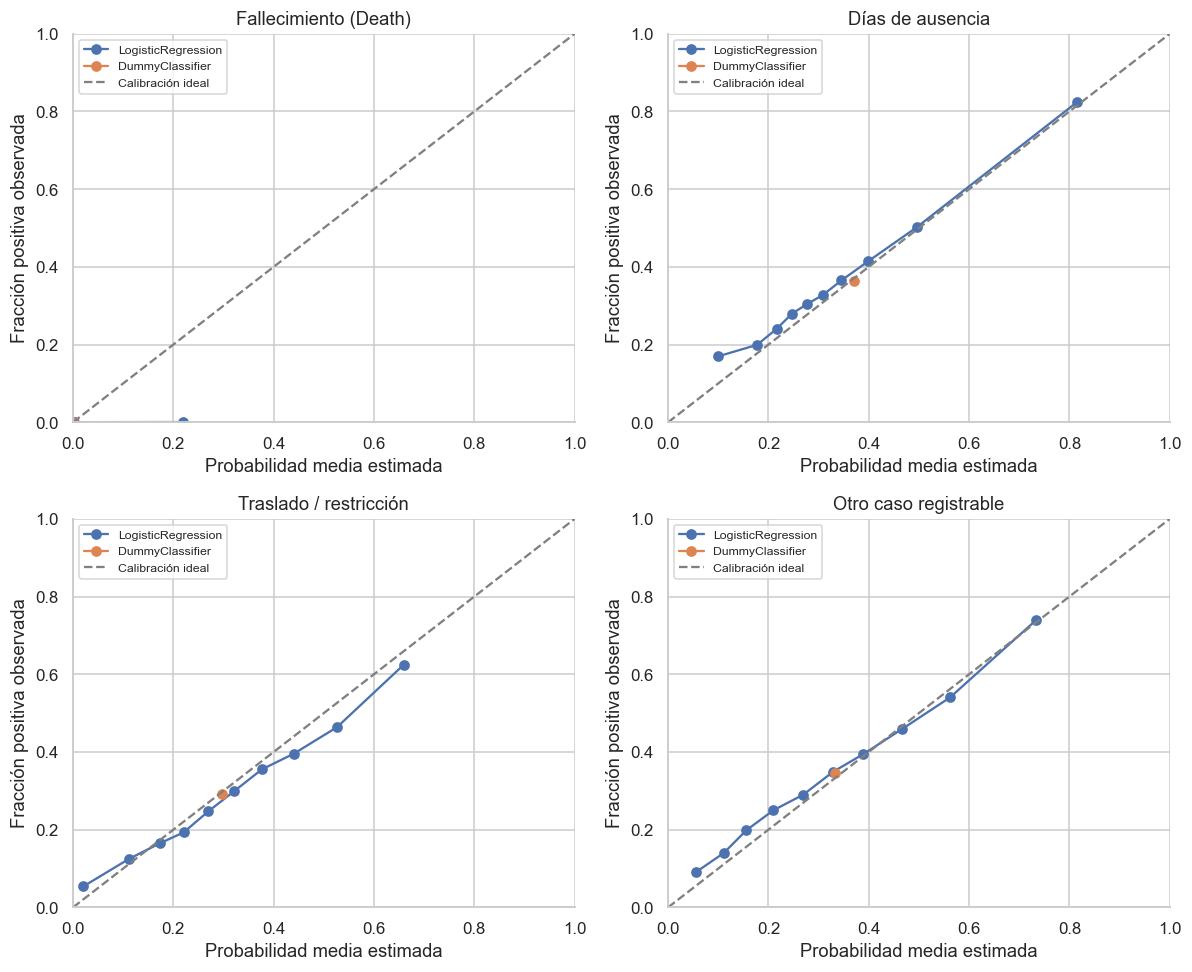

,LogisticRegression,DummyClassifier
Brier multiclase (menor es mejor),0.583329,0.664404
Pérdida logarítmica (menor es mejor),1.000859,1.097284


Brier multiclase: LR **0.5833**, Dummy **0.6644**. Pérdida logarítmica: LR **1.0009**, Dummy **1.0973**. Menor es mejor; mejora en discriminación no garantiza mejor calibración.

In [25]:
fig,axes=plt.subplots(2,2,figsize=(11,9))
for k,ax in enumerate(axes.flat):
    for model,p in probabilities.items():
        observed,estimated=calibration_curve(y_test==k+1,p[:,k],n_bins=10,strategy='quantile')
        ax.plot(estimated,observed,'o-',label=model)
    ax.plot([0,1],[0,1],'--',color='gray',label='Calibración ideal')
    ax.set(title=OUTCOMES[k+1],xlabel='Probabilidad media estimada',ylabel='Fracción positiva observada',xlim=(0,1),ylim=(0,1))
    ax.legend(fontsize=8)
plt.tight_layout();plt.show()
display(scores.loc[[METRIC_LABELS['brier_multiclass'],METRIC_LABELS['log_loss']]])

display(Markdown(f'Brier multiclase: LR **{evaluation["holdout_metrics"]["LogisticRegression"]["brier_multiclass"]:.4f}**, Dummy **{evaluation["holdout_metrics"]["DummyClassifier"]["brier_multiclass"]:.4f}**. Pérdida logarítmica: LR **{evaluation["holdout_metrics"]["LogisticRegression"]["log_loss"]:.4f}**, Dummy **{evaluation["holdout_metrics"]["DummyClassifier"]["log_loss"]:.4f}**. Menor es mejor; mejora en discriminación no garantiza mejor calibración.'))


## 21. Interpretación de coeficientes multinomiales

Se interpretan **contrastes entre categorías de un mismo predictor**, manteniendo los demás fijos. Para la clase k frente a «Otro caso registrable», el cambio de logaritmo de posibilidades al pasar de la categoría b a la a es:

`(beta[k,a] - beta[4,a]) - (beta[k,b] - beta[4,b])`.

Su exponencial es una razón de posibilidades relativa dentro del modelo. Esta comparación evita interpretar un indicador one-hot aislado como si las demás categorías del mismo predictor pudieran permanecer invariables. Se conserva la regularización y la ponderación balanceada; no se presentan intervalos inferenciales de los coeficientes. Las asociaciones **no son efectos causales**, pueden reflejar confusión y prácticas de reporte, y los coeficientes de Death son especialmente inestables. No se realiza selección de variables a partir de esta tabla.



In [26]:
final_model=joblib.load(CACHE_DIR/'final_lr.joblib')['model']
coefficient=pd.read_csv(CACHE_DIR/'coefficients.csv',index_col=0)
coefficient.columns=coefficient.columns.astype(int)
contrasts=[('type_of_incident','3','1','Afección respiratoria frente a lesión'),
           ('type_of_incident','5','1','Pérdida auditiva frente a lesión'),
           ('soc_code','29-1141','53-7062','Enfermería profesional frente a movimiento manual de materiales'),
           ('naics_code','622110','493110','Hospitales generales frente a almacenamiento general')]
rows=[]
for field,a,b,label in contrasts:
    ca,cb=f'{field}_{a}',f'{field}_{b}'
    if ca not in coefficient.index or cb not in coefficient.index:
        print('Contraste no disponible en la codificación:',field,a,b);continue
    for k in [1,2,3]:
        delta=float((coefficient.loc[ca,k]-coefficient.loc[ca,4])-(coefficient.loc[cb,k]-coefficient.loc[cb,4]))
        rows.append({'Predictor':field,'Comparación':label,'Clase frente a otro caso registrable':OUTCOMES[k],
                     'Cambio en logaritmo de posibilidades':delta,'Razón de posibilidades relativa':np.exp(delta)})
display(pd.DataFrame(rows))


,Predictor,Comparación,Clase frente a otro caso registrable,Cambio en logaritmo de posibilidades,Razón de posibilidades relativa
0,type_of_incident,Afección respiratoria frente a lesión,Fallecimiento (Death),3.802241,44.801477
1,type_of_incident,Afección respiratoria frente a lesión,Días de ausencia,2.937161,18.862224
2,type_of_incident,Afección respiratoria frente a lesión,Traslado / restricción,-1.146538,0.317735
3,type_of_incident,Pérdida auditiva frente a lesión,Fallecimiento (Death),-6.005091,0.002466
4,type_of_incident,Pérdida auditiva frente a lesión,Días de ausencia,-1.941407,0.143502
5,type_of_incident,Pérdida auditiva frente a lesión,Traslado / restricción,-1.932880,0.144731
6,soc_code,Enfermería profesional frente a movimiento man...,Fallecimiento (Death),-3.596801,0.027411
7,soc_code,Enfermería profesional frente a movimiento man...,Días de ausencia,-0.728608,0.482580
8,soc_code,Enfermería profesional frente a movimiento man...,Traslado / restricción,-0.612190,0.542162
9,naics_code,Hospitales generales frente a almacenamiento g...,Fallecimiento (Death),0.449517,1.567554


## 22. Conclusiones y límites

La prueba usa incidentes de octubre–diciembre en establecimientos completamente excluidos del desarrollo, con separación temporal y de grupos. La clasificación es retrospectiva y no valida un sistema de alerta operativa. El modelo supera o no supera la referencia según las métricas reportadas; esto no establece causas ni utilidad para decisiones laborales. La prueba tiene 39 fallecimientos en empresas distintas: es suficiente para calcular métricas, pero no para una afirmación precisa de desempeño en esa clase. El trimestre final ya se había examinado en análisis previos, por lo que la evaluación no es una reserva completamente inédita.


In [27]:
lr=evaluation['holdout_metrics']['LogisticRegression']; dummy=evaluation['holdout_metrics']['DummyClassifier']
display(Markdown(f'**Resultado del ajuste corregido:** exactitud balanceada **{lr["balanced_accuracy"]:.4f}** frente a **{dummy["balanced_accuracy"]:.4f}** de DummyClassifier; '
                 f'F1 macro **{lr["macro_f1"]:.4f}** frente a **{dummy["macro_f1"]:.4f}**; '
                 f'ROC AUC macro OvR **{lr["roc_auc_macro_ovr"]:.4f}** frente a **{dummy["roc_auc_macro_ovr"]:.4f}**. '
                 f'La exactitud es **{100*lr["accuracy"]:.2f} %** frente a **{100*dummy["accuracy"]:.2f} %**. '
                 f'El ajuste convergió en **{evaluation["final_fit"]["iterations"][0]} iteraciones**, sin seleccionar parámetros por estos resultados. '
                 'La comparación debe leerse junto con los intervalos agrupados, la validación interna, las métricas de Death y el diagnóstico de calibración.'))


**Resultado del ajuste corregido:** exactitud balanceada **0.4019** frente a **0.2500** de DummyClassifier; F1 macro **0.3966** frente a **0.1330**; ROC AUC macro OvR **0.6933** frente a **0.5000**. La exactitud es **52.38 %** frente a **36.24 %**. El ajuste convergió en **27 iteraciones**, sin seleccionar parámetros por estos resultados. La comparación debe leerse junto con los intervalos agrupados, la validación interna, las métricas de Death y el diagnóstico de calibración.

## 23. Reproducibilidad y análisis secundarios

Entorno existente `ml_env`; sin tuning. Los artefactos del protocolo grupo-tiempo se guardan separadamente de resultados históricos y llevan identidad de datos, código, parámetros, versiones y partición. El CSV original no se modifica. La ejecución genera la interpretación cuantitativa.

Los sectores se incluyen cuando tienen al menos 1.000 casos en desarrollo, criterio fijado sin consultar desempeño de prueba. Se muestran ambos modelos y soporte por clase. Una clase ausente impide AUC macro de cuatro clases; no se reemplaza por cero. Las diferencias sectoriales no se interpretan como rankings de seguridad.


,Paquete,Versión
0,numpy,1.23.5
1,pandas,1.5.3
2,scipy,1.10.1
3,scikit-learn,1.2.2
4,matplotlib,3.7.5
5,seaborn,0.12.2
6,joblib,1.5.3
7,threadpoolctl,3.7.0
8,ipython,8.18.1
9,ipykernel,6.30.1


Python: 3.9.25
Verificación final: datos y utilidades originales sin cambios; protocolo cronológico y predictores verificados.


### Desempeño por sector industrial

,sector,model,rows,establishments,accuracy,balanced_accuracy_present_classes,macro_f1_four_classes,class_support,auc_macro_ovr,accuracy_ci95,macro_f1_ci95,bootstrap_replicates
0,62,LogisticRegression,39169,6114,0.623733,0.397587,0.400784,"{'1': 3, '2': 15437, '3': 6296, '4': 17433}",0.724551,"[0.6139880544550576, 0.6340189635449669]","[0.39313819996026905, 0.4087321466086546]",500
1,62,DummyClassifier,39169,6114,0.394113,0.250000,0.141349,"{'1': 3, '2': 15437, '3': 6296, '4': 17433}",0.500000,"[0.3800436966999963, 0.4088725949398959]","[0.13769263144010585, 0.1451063056640785]",500
2,48-49,LogisticRegression,26451,5639,0.546520,0.331647,0.316891,"{'1': 9, '2': 10554, '3': 11492, '4': 4396}",0.659166,"[0.5314038582512246, 0.5596877097393728]","[0.3088271511401147, 0.32452082165650775]",500
3,48-49,DummyClassifier,26451,5639,0.399002,0.250000,0.142602,"{'1': 9, '2': 10554, '3': 11492, '4': 4396}",0.500000,"[0.3843362507892245, 0.4146719616291276]","[0.13881607320523476, 0.14656117206866578]",500
4,44-45,LogisticRegression,24326,9702,0.463660,0.335969,0.334052,"{'1': 3, '2': 8750, '3': 6042, '4': 9531}",0.608521,"[0.45584282331992243, 0.4718001541327423]","[0.32732289497214373, 0.34059172786290987]",500
5,44-45,DummyClassifier,24326,9702,0.359697,0.250000,0.132271,"{'1': 3, '2': 8750, '3': 6042, '4': 9531}",0.500000,"[0.35174310321319935, 0.36881690727046107]","[0.13010723030788449, 0.134721051921266]",500
6,31-33,LogisticRegression,19678,6866,0.448724,0.339999,0.314570,"{'1': 12, '2': 5325, '3': 7260, '4': 7081}",0.632741,"[0.43519781829790877, 0.46133719360562536]","[0.30515322083197227, 0.323241325443727]",500
7,31-33,DummyClassifier,19678,6866,0.270607,0.250000,0.106487,"{'1': 12, '2': 5325, '3': 7260, '4': 7081}",0.500000,"[0.25978552389207815, 0.28334489329371354]","[0.10310704439807225, 0.1103930967286367]",500
8,42,LogisticRegression,4868,1630,0.470830,0.310878,0.309838,"{'1': 2, '2': 1950, '3': 1949, '4': 967}",0.664860,"[0.4499721179382461, 0.48944663872054206]","[0.29369843952624514, 0.32297795971622417]",500
9,42,DummyClassifier,4868,1630,0.400575,0.250000,0.143004,"{'1': 2, '2': 1950, '3': 1949, '4': 967}",0.500000,"[0.37798765266507206, 0.4217108659589385]","[0.13715204627543304, 0.1483110138190617]",500


### Separación por establecimiento

Establecimientos de desarrollo: 34029
Establecimientos de prueba: 34182
Establecimientos compartidos: 0
Filas excluidas por la combinación de empresa, tiempo y purga: 493465
Establishment bootstrap is conditional on the fixed quarter and fitted models; it does not cover common calendar shocks or training uncertainty.


### Dependencia temporal de los errores

,ACF de la tasa diaria de error
1,0.259542
2,0.165501
7,0.313392
14,0.402683


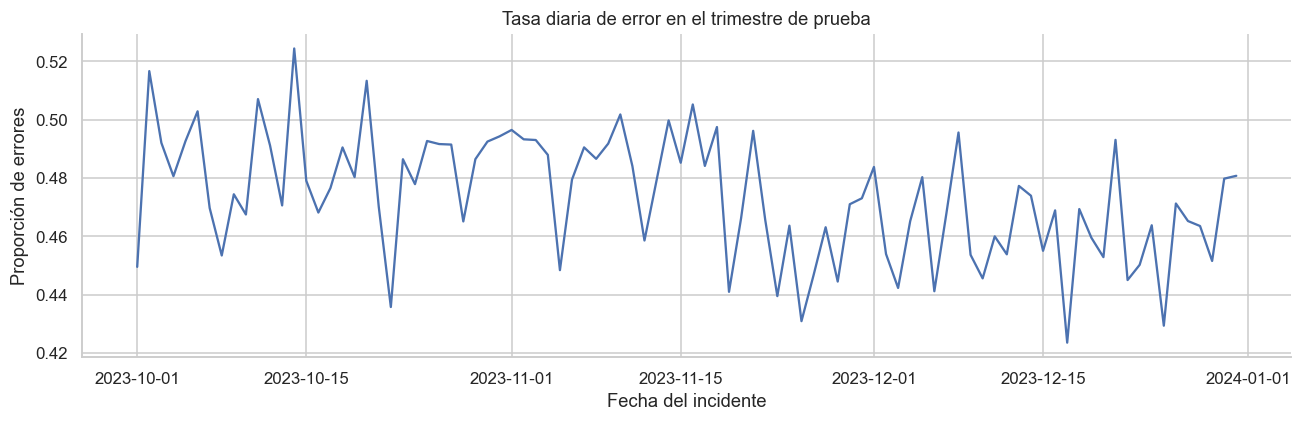

Las diferencias entre sectores se interpretan junto con soporte y los intervalos agrupados. No prueban diferencias causales ni riesgo de sufrir una lesión. La autocorrelación diaria es descriptiva y puede reflejar cambios de composición.

### Deriva descriptiva entre periodos de desarrollo

,Predictor,Distancia de variación total Q1–Q3
0,state,0.027941
1,naics_code,0.057515
2,establishment_type,0.012856
3,soc_code,0.038296
4,type_of_incident,0.018250
5,time_unknown,0.006887
6,time_started_work_hour,0.022089
7,time_of_incident_hour,0.016785


La deriva se calcula dentro del desarrollo. Cambios en composición no demuestran cambios en la relación causal ni concept drift por sí solos. La publicación de un solo año limita conclusiones sobre ciclos anuales.

In [28]:
from importlib.metadata import version
package_names=['numpy','pandas','scipy','scikit-learn','matplotlib','seaborn','joblib','threadpoolctl','ipython','ipykernel','jupyter-client','statsmodels','jupyter-book','nbclient','nbformat','psutil']
versions=pd.DataFrame({'Paquete':package_names,'Versión':[version(name) for name in package_names]})
display(versions)
print('Python:',sys.version.split()[0])
assert (DATA_PATH.stat().st_size,DATA_PATH.stat().st_mtime_ns)==raw_signature
assert hashlib.sha256(UTILS_PATH.read_bytes()).hexdigest()==utils_hash
assert evaluation['features']==baseline['features']
assert evaluation['train_rows']==len(train) and evaluation['test_rows']==holdout_rows
assert evaluation['group_overlap']==0 and evaluation['test_death_groups']==39
assert evaluation['train_rows']==len(train) and evaluation['test_rows']==holdout_rows
assert evaluation['group_overlap']==0 and evaluation['test_death_groups']==39
assert evaluation['final_fit']['converged'] and all(r['converged'] for r in evaluation['learning_curve'])
assert len(plt.get_fignums())==0
print('Verificación final: datos y utilidades originales sin cambios; protocolo cronológico y predictores verificados.')

sector_table=pd.DataFrame([{k:v for k,v in r.items() if k!='classification_report'} for r in evaluation['sector_analysis']])
display(Markdown('### Desempeño por sector industrial'))
display(sector_table)
display(Markdown('### Separación por establecimiento'))
print('Establecimientos de desarrollo:', evaluation['train_groups'])
print('Establecimientos de prueba:', evaluation['test_groups'])
print('Establecimientos compartidos:', evaluation['group_overlap'])
print('Filas excluidas por la combinación de empresa, tiempo y purga:', evaluation['excluded_2023_rows'])
print(evaluation['uncertainty_limit'])

display(Markdown('### Dependencia temporal de los errores'))
display(pd.Series(evaluation['daily_error_rate_acf'],name='ACF de la tasa diaria de error').to_frame())
daily_error=pd.read_csv(CACHE_DIR/'daily_test_errors.csv',parse_dates=['date'])
fig,ax=plt.subplots(figsize=(12,4))
ax.plot(daily_error.date,daily_error['mean'])
ax.set(title='Tasa diaria de error en el trimestre de prueba',xlabel='Fecha del incidente',ylabel='Proporción de errores')
plt.tight_layout();plt.show()
display(Markdown('Las diferencias entre sectores se interpretan junto con soporte y los intervalos agrupados. No prueban diferencias causales ni riesgo de sufrir una lesión. La autocorrelación diaria es descriptiva y puede reflejar cambios de composición.'))

display(Markdown('### Deriva descriptiva entre periodos de desarrollo'))
drift=[]
for field in baseline['features']:
    z=feature_view[field].astype(object).fillna('Unknown').astype(str)
    early=z.loc[train.incident_date.lt('2023-04-01')].value_counts(normalize=True)
    late=z.loc[train.incident_date.ge('2023-07-01')].value_counts(normalize=True)
    categories=early.index.union(late.index)
    drift.append({'Predictor':field,'Distancia de variación total Q1–Q3':float(.5*(early.reindex(categories,fill_value=0)-late.reindex(categories,fill_value=0)).abs().sum())})
display(pd.DataFrame(drift))
display(Markdown('La deriva se calcula dentro del desarrollo. Cambios en composición no demuestran cambios en la relación causal ni concept drift por sí solos. La publicación de un solo año limita conclusiones sobre ciclos anuales.'))
